* **`Scenario`**: identificativo dello scenario considerato, cioè della specifica configurazione di rete e di placement analizzata.

* **`App_ms`**: identificativo completo dell’applicazione o catena di microservizi considerata.

* **`App_group`**: versione aggregata di `App_ms` che ignora il prefisso numerico iniziale e mantiene solo la struttura dell’applicazione.

* **`Assignment_Cost`**: somma dei pesi `c_i` dei nodi su cui sono stati deployati i servizi dell’applicazione.  
  Se `x_ui` è la variabile binaria di assegnazione che vale `1` quando il servizio `u` è deployato sul nodo `i` e `0` altrimenti, allora questa metrica rappresenta il contributo del placement alla funzione obiettivo nella forma:

  $$
  \sum_u \sum_i x_{ui} c_i
  $$

* **`Service_Weighted_Assignment_Cost`**: somma dei pesi dei nodi ulteriormente pesata con la domanda di CPU dei servizi.  
  Se `q_u` è la domanda di CPU del servizio `u`, allora questa metrica corrisponde al termine:

  $$
  \sum_u \sum_i x_{ui} q_u c_i
  $$

  e misura quindi il costo del placement tenendo conto anche della “dimensione” dei servizi.

* **`Num_Services`**: numero totale di servizi dell’applicazione che risultano effettivamente assegnati a un nodo.

* **`Used_Nodes_Count`**: numero di nodi distinti utilizzati per ospitare i servizi dell’applicazione.

* **`Zero_Cost_Used_Nodes`**: numero di nodi utilizzati che hanno peso `c_i = 0`, utile per verificare se il costo del placement è influenzato dalla presenza di nodi a costo nullo.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path
from analysis.utils.scenario_utils import build_objective_cost_dataset, build_resource_stress_dataset

FIGURES_DIR = Path("plot_figures")
FIGURES_DIR.mkdir(exist_ok=True)

distribution_labels = {
    "deterministic": "Deterministic",
    "uniform": "Uniform",
    "normal": "Normal",
    "normal_wide": "Normal wide",
    "normal_wide_trunc": "Normal wide trunc",
    "gamma_k2": "Gamma k=2",
    "exponential": "Exponential",
}

df = pd.read_pickle("processed_data/dataset_worst_case_scenarios.pkl")
df.head()

,Distribution,Scenario,App_ms,App_group,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Margin,SLA_Margin_Perc,Violation_Amount,Processing Delay,Propagation Delay
0,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_392,1,1,58,63.924,False,-5.924,-9.267,0.0,33,25
1,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_619,2,2,49,63.924,False,-14.924,-23.346,0.0,23,26
2,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_976,2,2,53,63.924,False,-10.924,-17.089,0.0,27,26
3,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_338,1,1,56,63.924,False,-7.924,-12.396,0.0,31,25
4,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_235,1,1,55,63.924,False,-8.924,-13.960,0.0,30,25


In [64]:
objective_df = build_objective_cost_dataset()
objective_df['Assignment_Cost'].unique()
len(objective_df['Assignment_Cost'].unique())

35

In [65]:
scatter_df = df.merge(
    objective_df,
    on=["Scenario", "App_ms", "App_group"],
    how="left"
)

scatter_df.head()

,Distribution,Scenario,App_ms,App_group,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Margin,SLA_Margin_Perc,Violation_Amount,Processing Delay,Propagation Delay,Assignment_Cost,Service_Weighted_Assignment_Cost,Num_Services,Used_Nodes_Count,Zero_Cost_Used_Nodes
0,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_392,1,1,58,63.924,False,-5.924,-9.267,0.0,33,25,0.773889,12.444444,10,6,1
1,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_619,2,2,49,63.924,False,-14.924,-23.346,0.0,23,26,0.773889,12.444444,10,6,1
2,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_976,2,2,53,63.924,False,-10.924,-17.089,0.0,27,26,0.773889,12.444444,10,6,1
3,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_338,1,1,56,63.924,False,-7.924,-12.396,0.0,31,25,0.773889,12.444444,10,6,1
4,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_235,1,1,55,63.924,False,-8.924,-13.960,0.0,30,25,0.773889,12.444444,10,6,1


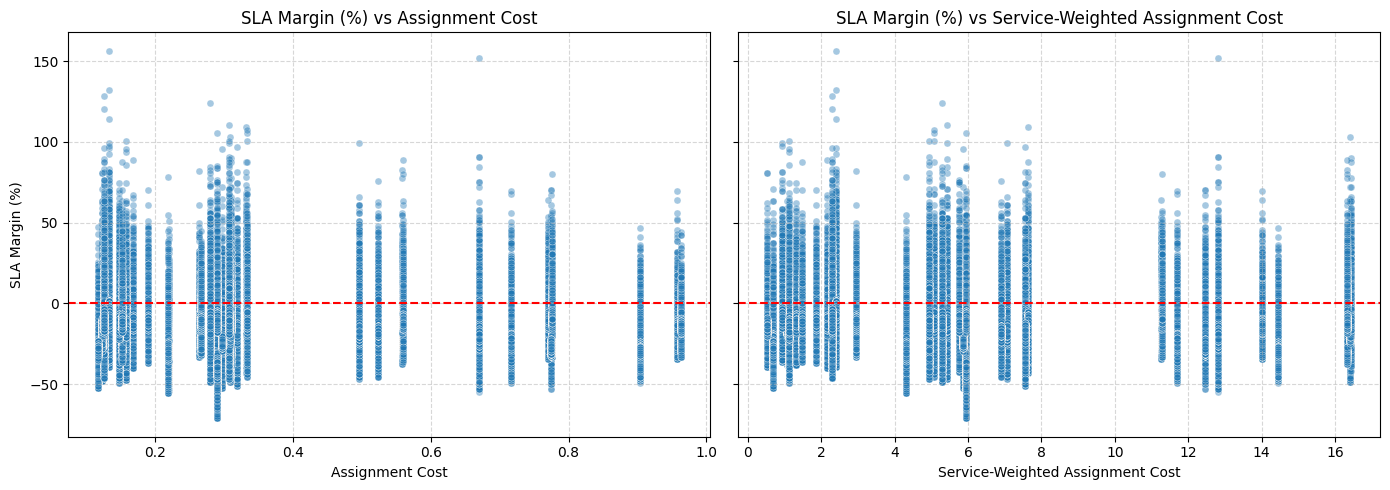

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.scatterplot(
    data=scatter_df,
    x="Assignment_Cost",
    y="SLA_Margin_Perc",
    alpha=0.4,
    s=25,
    ax=axes[0],
    legend=False
)

axes[0].axhline(0, linestyle="--", color="red")
axes[0].set_title("SLA Margin (%) vs Assignment Cost")
axes[0].set_xlabel("Assignment Cost")
axes[0].set_ylabel("SLA Margin (%)")
axes[0].grid(True, linestyle="--", alpha=0.5)

sns.scatterplot(
    data=scatter_df,
    x="Service_Weighted_Assignment_Cost",
    y="SLA_Margin_Perc",
    alpha=0.4,
    s=25,
    ax=axes[1],
    legend=False
)

axes[1].axhline(0, linestyle="--", color="red")
axes[1].set_title("SLA Margin (%) vs Service-Weighted Assignment Cost")
axes[1].set_xlabel("Service-Weighted Assignment Cost")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [67]:
agg_df = (
    scatter_df.groupby(["Distribution", "App_group"])
    .agg(
        Mean_SLA_Margin_Perc=("SLA_Margin_Perc", "mean"),
        Median_SLA_Margin_Perc=("SLA_Margin_Perc", "median"),
        Violation_Rate=("SLA_Violation", "mean"),
        Mean_Assignment_Cost=("Assignment_Cost", "mean"),
        Mean_Service_Weighted_Assignment_Cost=("Service_Weighted_Assignment_Cost", "mean"),
        Mean_Zero_Cost_Used_Nodes=("Zero_Cost_Used_Nodes", "mean"),
    )
    .reset_index()
)

agg_df["Violation_Rate"] = agg_df["Violation_Rate"] * 100
agg_df.head()

,Distribution,App_group,Mean_SLA_Margin_Perc,Median_SLA_Margin_Perc,Violation_Rate,Mean_Assignment_Cost,Mean_Service_Weighted_Assignment_Cost,Mean_Zero_Cost_Used_Nodes
0,deterministic,MMM,-19.83200,-16.4990,0.0,0.353333,6.312500,0.75
1,deterministic,MMS,-11.12375,-8.0730,0.0,0.360000,6.221667,1.00
2,deterministic,MSM,-26.70900,-26.7090,0.0,0.510000,7.558333,1.50
3,deterministic,MSS,-23.23750,-23.2375,0.0,0.513333,7.565000,1.50
4,deterministic,SMM,-12.65070,-11.2355,0.0,0.372056,8.338333,1.00


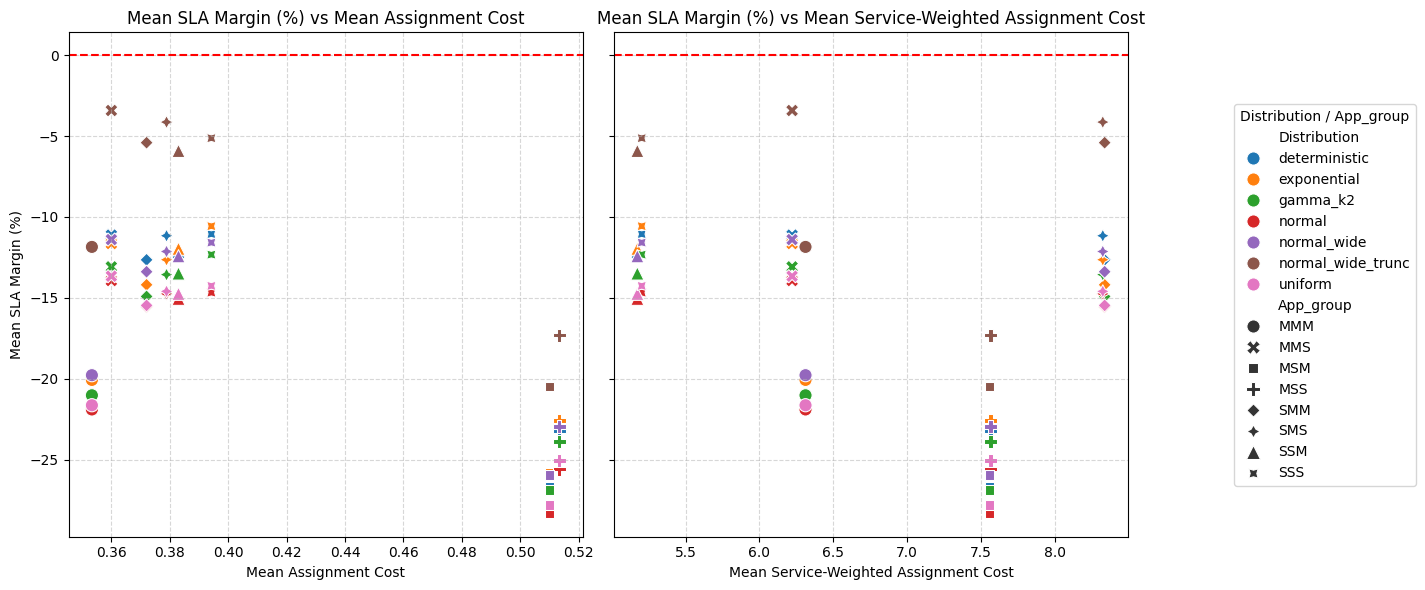

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

common_kwargs = dict(
    data=agg_df,
    y="Mean_SLA_Margin_Perc",
    hue="Distribution",
    style="App_group",
    s=90
)

sns.scatterplot(
    x="Mean_Assignment_Cost",
    ax=axes[0],
    legend=True,
    **common_kwargs
)

axes[0].axhline(0, linestyle="--", color="red")
axes[0].set_title("Mean SLA Margin (%) vs Mean Assignment Cost")
axes[0].set_xlabel("Mean Assignment Cost")
axes[0].set_ylabel("Mean SLA Margin (%)")
axes[0].grid(True, linestyle="--", alpha=0.5)

sns.scatterplot(
    x="Mean_Service_Weighted_Assignment_Cost",
    ax=axes[1],
    legend=False,
    **common_kwargs
)

axes[1].axhline(0, linestyle="--", color="red")
axes[1].set_title("Mean SLA Margin (%) vs Mean Service-Weighted Assignment Cost")
axes[1].set_xlabel("Mean Service-Weighted Assignment Cost")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle="--", alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    frameon=True,
    title="Distribution / App_group"
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

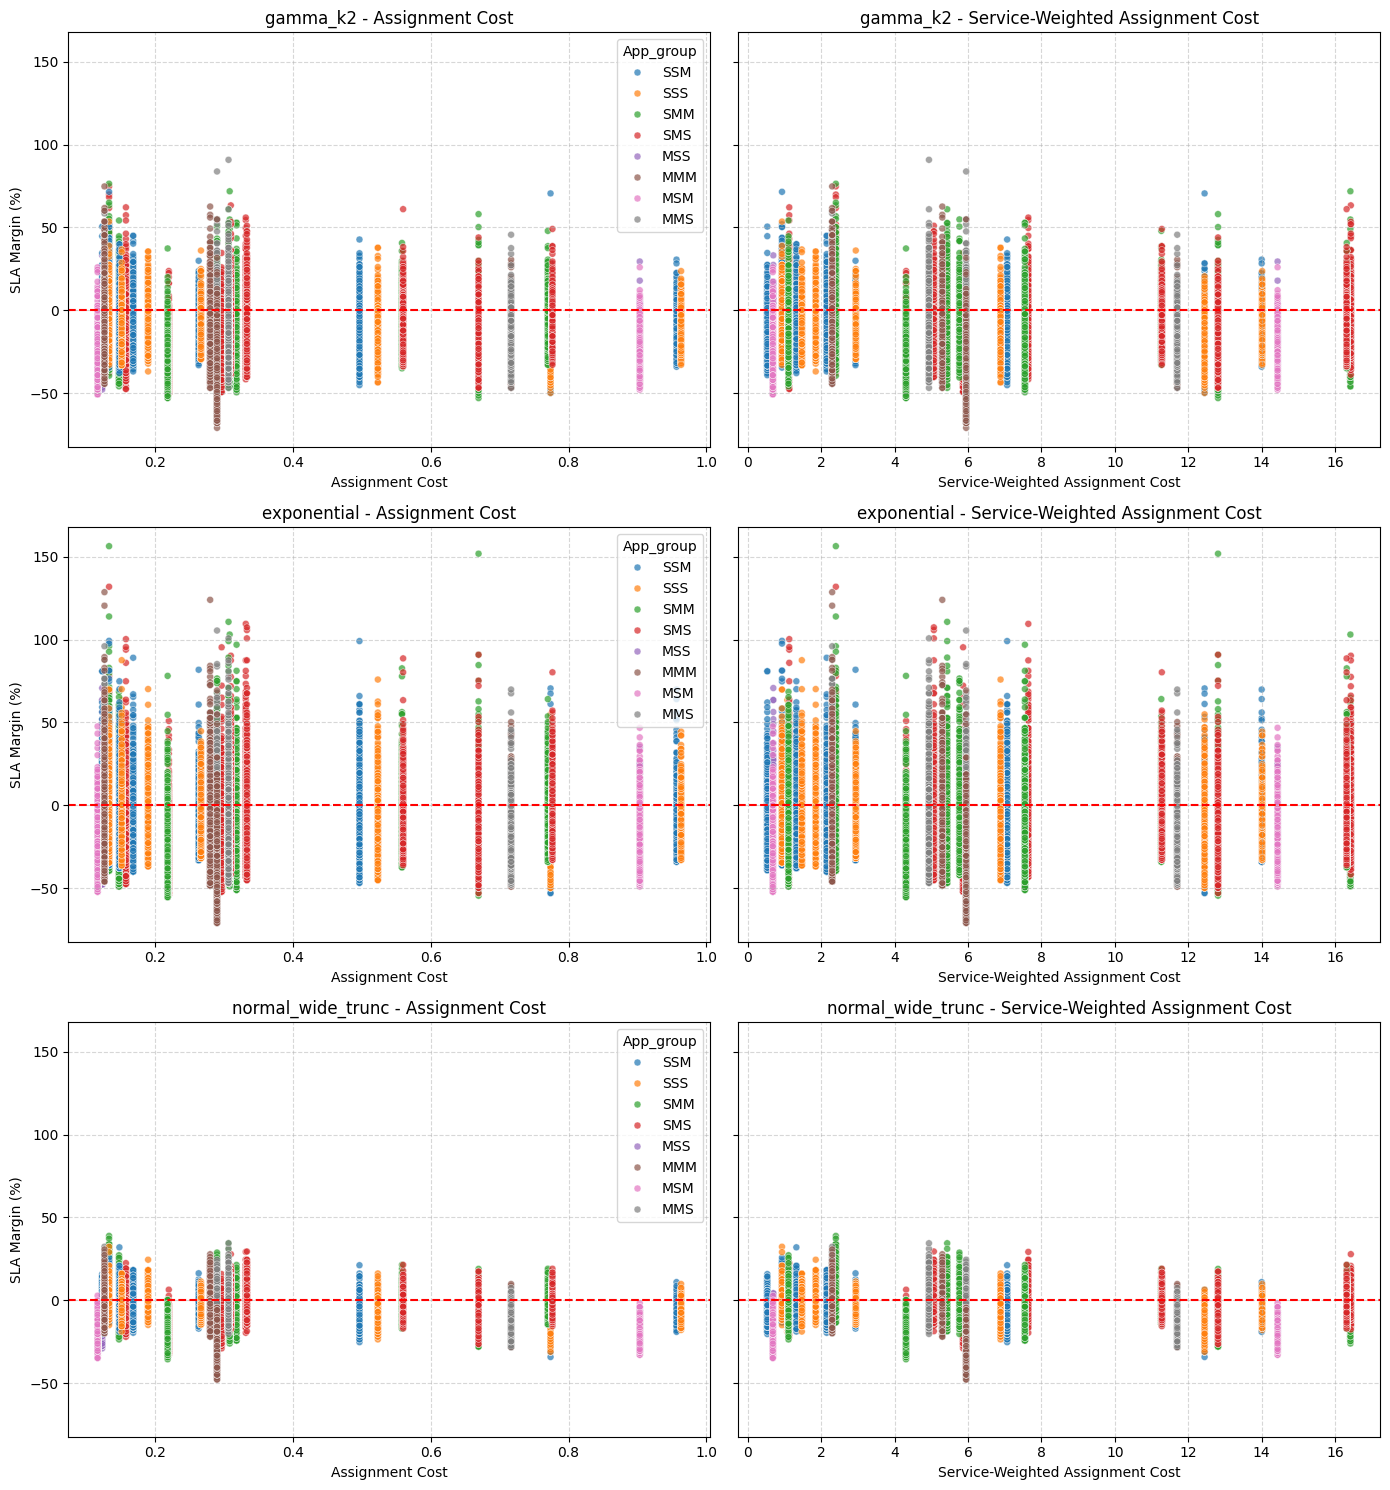

In [69]:
dists = ["gamma_k2", "exponential", "normal_wide_trunc"]

fig, axes = plt.subplots(
    nrows=len(dists),
    ncols=2,
    figsize=(14, 5 * len(dists)),
    sharey=True
)

if len(dists) == 1:
    axes = np.array([axes])

for i, dist_to_plot in enumerate(dists):
    plot_df = scatter_df[scatter_df["Distribution"] == dist_to_plot].copy()

    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    sns.scatterplot(
        data=plot_df,
        x="Assignment_Cost",
        y="SLA_Margin_Perc",
        hue="App_group",
        alpha=0.7,
        s=25,
        ax=ax_left,
    )

    sns.scatterplot(
        data=plot_df,
        x="Service_Weighted_Assignment_Cost",
        y="SLA_Margin_Perc",
        hue="App_group",
        alpha=0.7,
        s=25,
        ax=ax_right,
        legend=False
    )

    ax_left.axhline(0, linestyle="--", color="red")
    ax_left.set_title(f"{dist_to_plot} - Assignment Cost")
    ax_left.set_xlabel("Assignment Cost")
    ax_left.set_ylabel("SLA Margin (%)")
    ax_left.grid(True, linestyle="--", alpha=0.5)

    ax_right.axhline(0, linestyle="--", color="red")
    ax_right.set_title(f"{dist_to_plot} - Service-Weighted Assignment Cost")
    ax_right.set_xlabel("Service-Weighted Assignment Cost")
    ax_right.set_ylabel("")
    ax_right.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

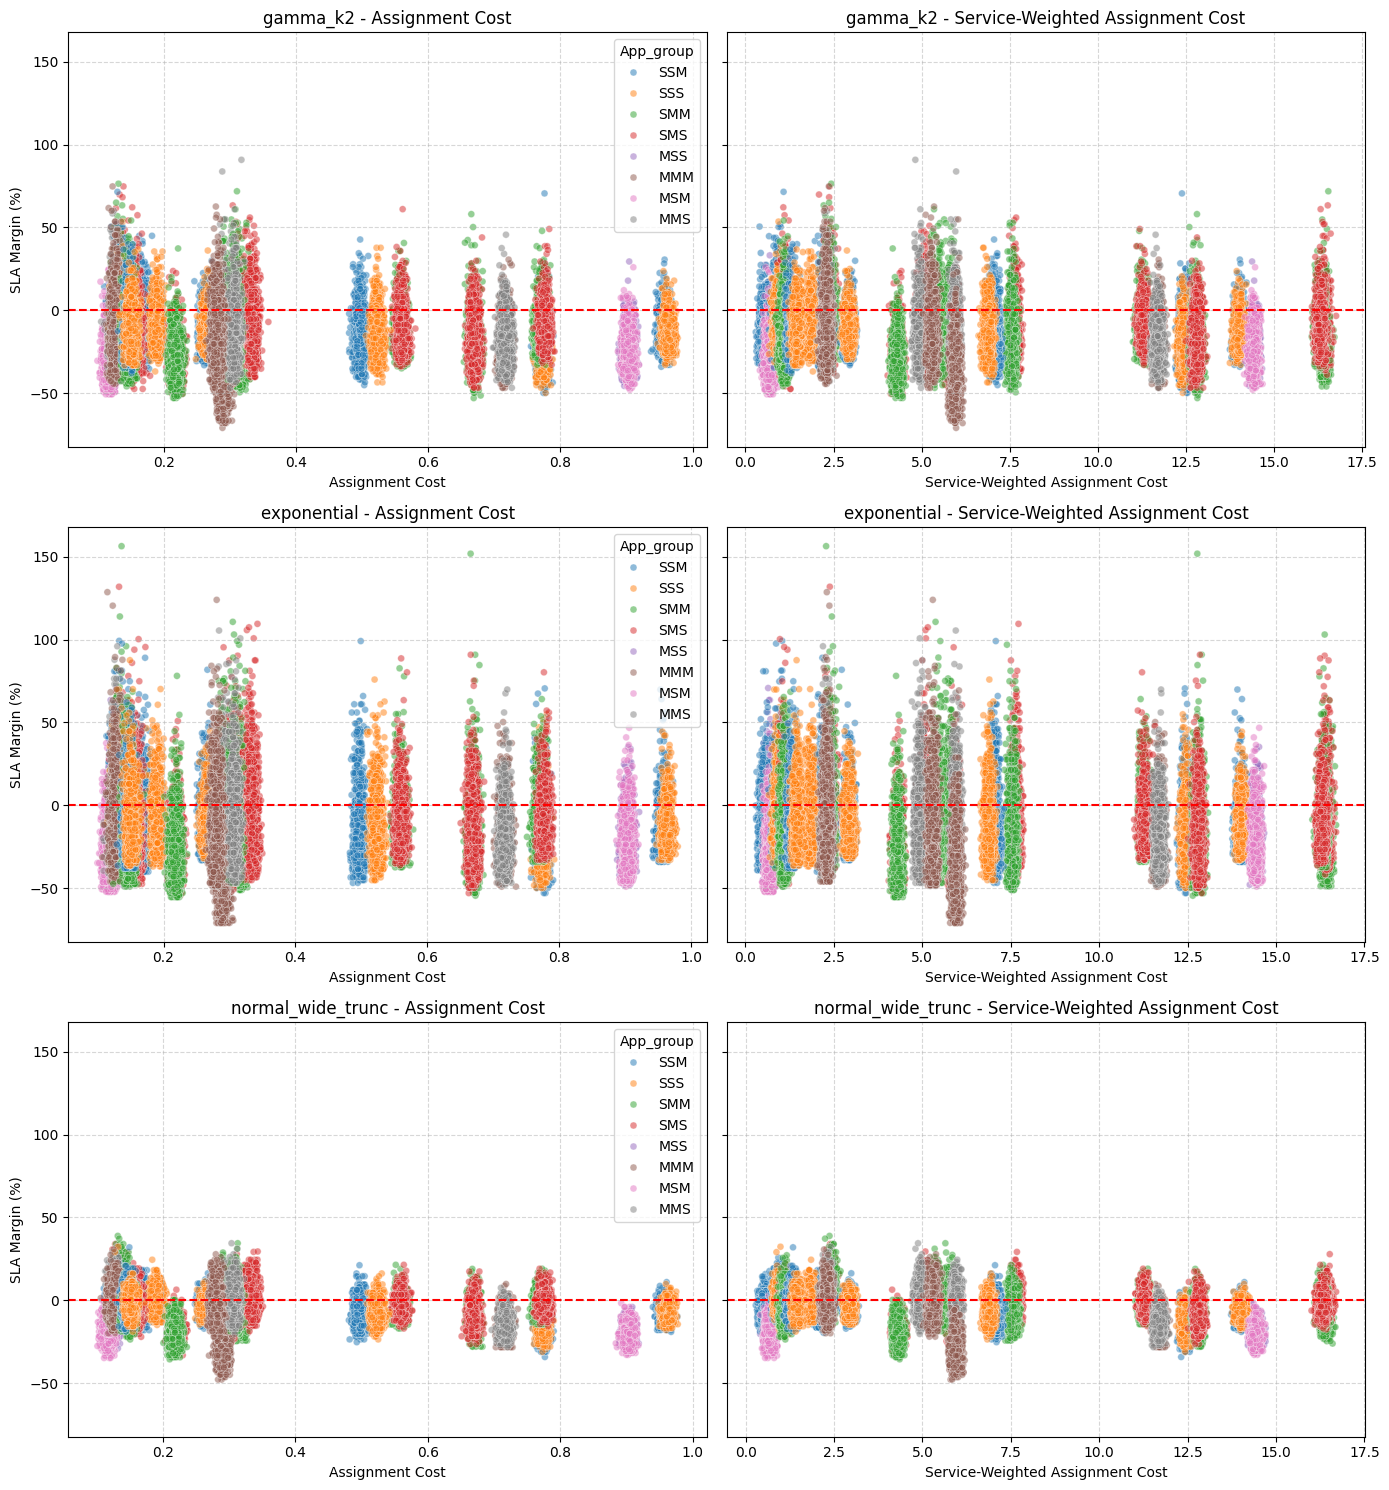

In [70]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(
    nrows=len(dists),
    ncols=2,
    figsize=(14, 5 * len(dists)),
    sharey=True
)

if len(dists) == 1:
    axes = np.array([axes])

jitter_node = 0.005
jitter_weighted = 0.08

for i, dist_to_plot in enumerate(dists):
    plot_df = scatter_df[scatter_df["Distribution"] == dist_to_plot].copy()

    plot_df["Assignment_Cost_Jitter"] = (
        plot_df["Assignment_Cost"] + rng.normal(0, jitter_node, size=len(plot_df))
    )
    plot_df["Service_Weighted_Assignment_Cost_Jitter"] = (
        plot_df["Service_Weighted_Assignment_Cost"] + rng.normal(0, jitter_weighted, size=len(plot_df))
    )

    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    sns.scatterplot(
        data=plot_df,
        x="Assignment_Cost_Jitter",
        y="SLA_Margin_Perc",
        hue="App_group",
        alpha=0.5,
        s=25,
        ax=ax_left,
    )

    sns.scatterplot(
        data=plot_df,
        x="Service_Weighted_Assignment_Cost_Jitter",
        y="SLA_Margin_Perc",
        hue="App_group",
        alpha=0.5,
        s=25,
        ax=ax_right,
        legend=False
    )

    ax_left.axhline(0, linestyle="--", color="red")
    ax_left.set_title(f"{dist_to_plot} - Assignment Cost")
    ax_left.set_xlabel("Assignment Cost")
    ax_left.set_ylabel("SLA Margin (%)")
    ax_left.grid(True, linestyle="--", alpha=0.5)

    ax_right.axhline(0, linestyle="--", color="red")
    ax_right.set_title(f"{dist_to_plot} - Service-Weighted Assignment Cost")
    ax_right.set_xlabel("Service-Weighted Assignment Cost")
    ax_right.set_ylabel("")
    ax_right.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

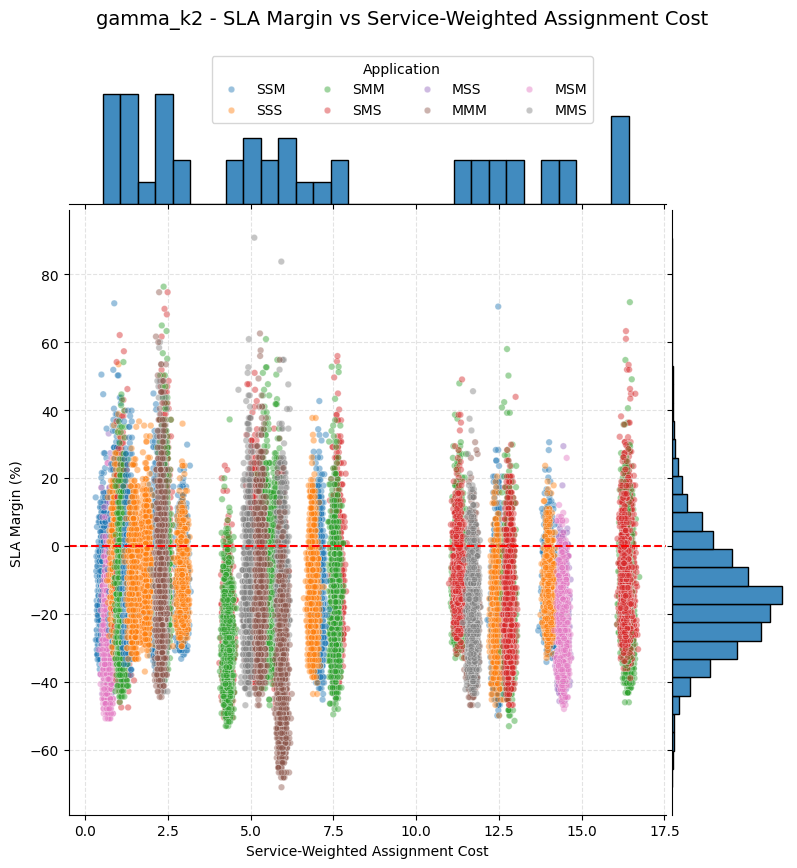

In [71]:
dist_to_plot = "gamma_k2"

plot_df = scatter_df[scatter_df["Distribution"] == dist_to_plot].copy()

rng = np.random.default_rng(42)

plot_df["Service_Weighted_Assignment_Cost_Jitter"] = (
    plot_df["Service_Weighted_Assignment_Cost"]
    + rng.normal(0, 0.08, size=len(plot_df))
)

g = sns.JointGrid(
    data=plot_df,
    x="Service_Weighted_Assignment_Cost_Jitter",
    y="SLA_Margin_Perc",
    height=8,
    ratio=5,
    space=0.05
)

sns.scatterplot(
    data=plot_df,
    x="Service_Weighted_Assignment_Cost_Jitter",
    y="SLA_Margin_Perc",
    hue="App_group",
    alpha=0.45,
    s=22,
    ax=g.ax_joint
)

sns.histplot(
    data=plot_df,
    x="Service_Weighted_Assignment_Cost",
    bins=30,
    alpha=0.85,
    ax=g.ax_marg_x
)

sns.histplot(
    data=plot_df,
    y="SLA_Margin_Perc",
    bins=30,
    alpha=0.85,
    ax=g.ax_marg_y
)

g.ax_joint.axhline(0, linestyle="--", color="red")

g.ax_joint.set_xlabel("Service-Weighted Assignment Cost")
g.ax_joint.set_ylabel("SLA Margin (%)")

g.ax_joint.grid(True, linestyle="--", alpha=0.35)
g.ax_marg_x.grid(False)
g.ax_marg_y.grid(False)

g.ax_marg_x.set_xlabel("")
g.ax_marg_x.set_ylabel("")
g.ax_marg_y.set_xlabel("")
g.ax_marg_y.set_ylabel("")

g.ax_marg_x.tick_params(axis="x", labelbottom=False)
g.ax_marg_y.tick_params(axis="y", labelleft=False)

handles, labels = g.ax_joint.get_legend_handles_labels()

if g.ax_joint.get_legend() is not None:
    g.ax_joint.get_legend().remove()

g.fig.legend(
    handles,
    labels,
    title="Application",
    loc="upper center",
    ncol=min(len(labels), 4),
    bbox_to_anchor=(0.5, 1.03),
    frameon=True
)

g.fig.suptitle(
    f"{dist_to_plot} - SLA Margin vs Service-Weighted Assignment Cost",
    y=1.08,
    fontsize=14
)

plt.show()

In [72]:
cost_sla_summary = (
    scatter_df
    .groupby(["Distribution", "Scenario", "App_group"])
    .agg(
        Median_SLA_Margin_Perc=("SLA_Margin_Perc", "median"),
        Q25_SLA_Margin_Perc=("SLA_Margin_Perc", lambda x: x.quantile(0.25)),
        Q75_SLA_Margin_Perc=("SLA_Margin_Perc", lambda x: x.quantile(0.75)),
        Violation_Rate=("SLA_Violation", "mean"),
        Service_Weighted_Assignment_Cost=("Service_Weighted_Assignment_Cost", "first"),
        Assignment_Cost=("Assignment_Cost", "first"),
        Runs=("Run", "count")
    )
    .reset_index()
)

cost_sla_summary["Violation_Rate"] = cost_sla_summary["Violation_Rate"] * 100

cost_sla_summary.head()

,Distribution,Scenario,App_group,Median_SLA_Margin_Perc,Q25_SLA_Margin_Perc,Q75_SLA_Margin_Perc,Violation_Rate,Service_Weighted_Assignment_Cost,Assignment_Cost,Runs
0,deterministic,1_26_solution_v0,SMM,-14.942,-14.942,-14.942,0.0,7.550000,0.318333,1000
1,deterministic,1_26_solution_v0,SMS,-7.066,-7.066,-7.066,0.0,7.643333,0.331667,1000
2,deterministic,1_26_solution_v0,SSM,-10.216,-10.216,-10.216,0.0,2.150000,0.168333,1000
3,deterministic,1_26_solution_v0,SSS,-7.066,-7.066,-7.066,0.0,1.851667,0.190000,1000
4,deterministic,1_26_solution_v10,MMM,-37.782,-37.782,-37.782,0.0,5.950000,0.290000,1000


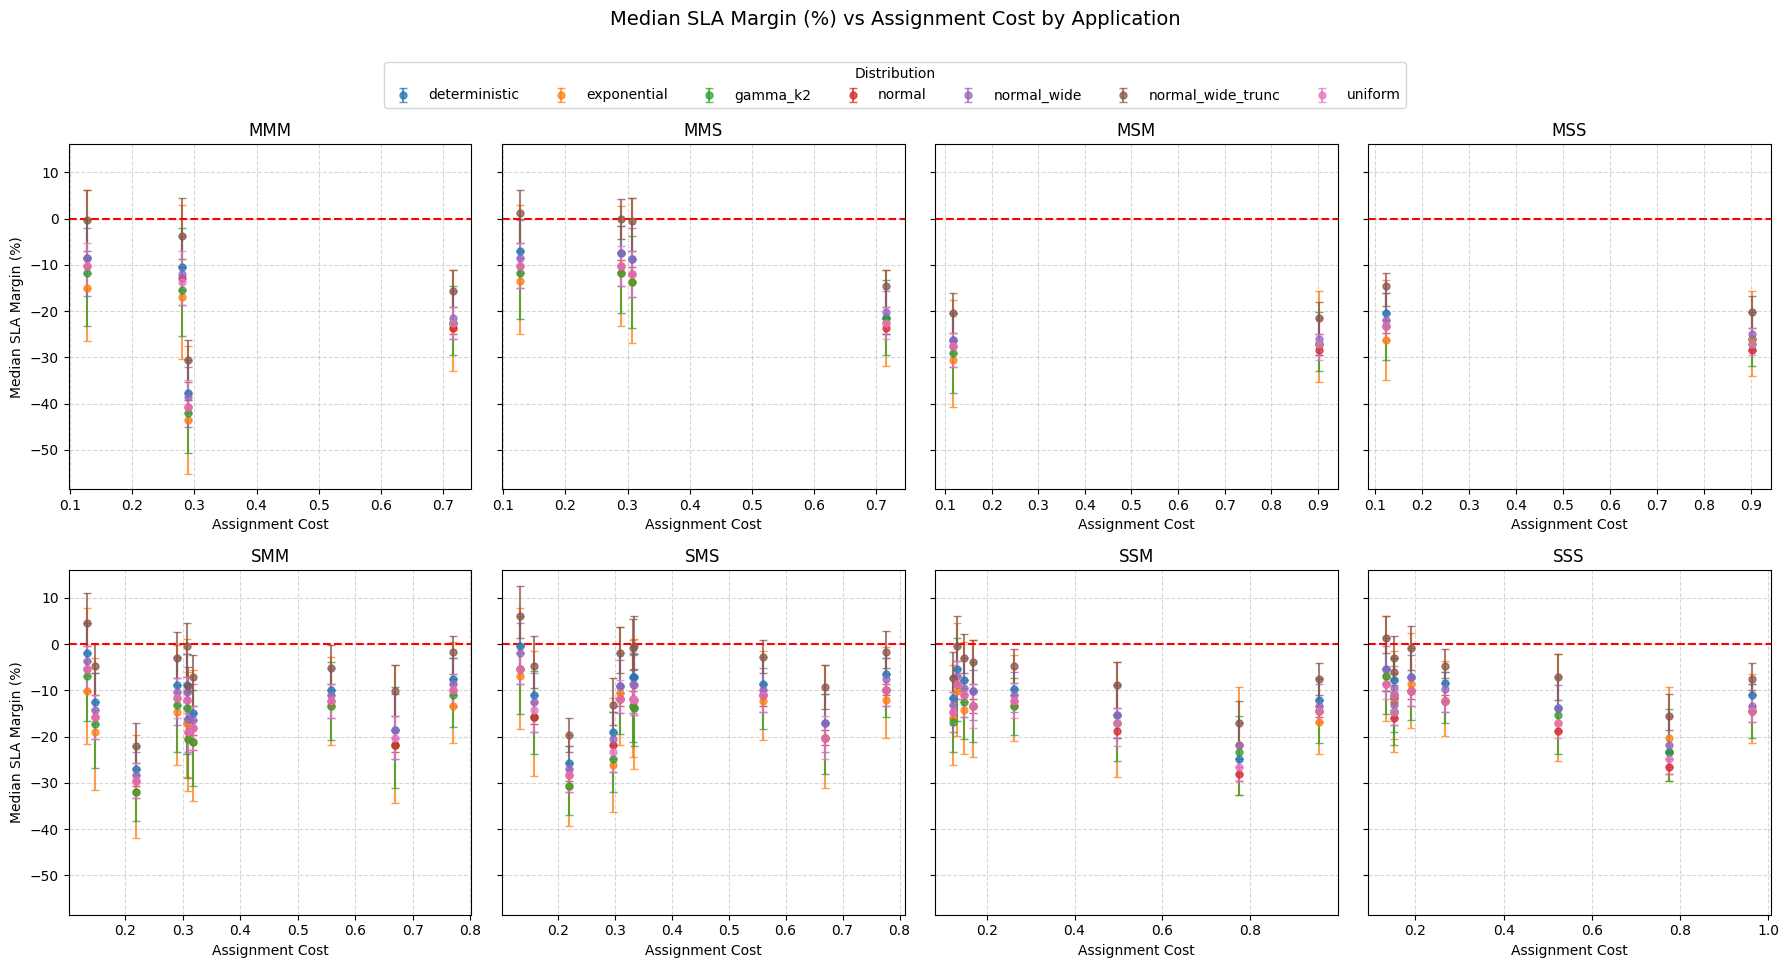

In [73]:
#dists = ["gamma_k2", "exponential", "normal_wide_trunc"]

# plot_df = cost_sla_summary[
#     cost_sla_summary["Distribution"].isin(dists)
# ].copy()

# app_groups = sorted(plot_df["App_group"].dropna().unique())
# palette = dict(zip(dists, sns.color_palette("tab10", n_colors=len(dists))))

dists = sorted(cost_sla_summary["Distribution"].dropna().unique())

plot_df = cost_sla_summary[
    cost_sla_summary["Distribution"].isin(dists)
].copy()

app_groups = sorted(plot_df["App_group"].dropna().unique())
palette = dict(zip(dists, sns.color_palette("tab10", n_colors=len(dists))))

ncols = 4
nrows = math.ceil(len(app_groups) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 4.5 * nrows),
    sharey=True
)

axes = axes.flatten()

for i, app_group in enumerate(app_groups):
    ax = axes[i]
    subset_app = plot_df[plot_df["App_group"] == app_group]

    for dist in dists:
        subset = subset_app[subset_app["Distribution"] == dist]

        yerr_lower = subset["Median_SLA_Margin_Perc"] - subset["Q25_SLA_Margin_Perc"]
        yerr_upper = subset["Q75_SLA_Margin_Perc"] - subset["Median_SLA_Margin_Perc"]

        ax.errorbar(
            subset["Assignment_Cost"],
            subset["Median_SLA_Margin_Perc"],
            yerr=[yerr_lower, yerr_upper],
            fmt="o",
            markersize=5,
            alpha=0.75,
            capsize=3,
            label=dist,
            color=palette[dist]
        )

    ax.axhline(0, linestyle="--", color="red")
    ax.set_title(app_group)
    ax.set_xlabel("Assignment Cost")
    ax.grid(True, linestyle="--", alpha=0.5)

    if i % ncols == 0:
        ax.set_ylabel("Median SLA Margin (%)")
    else:
        ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Distribution",
    loc="upper center",
    ncol=len(dists),
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "Median SLA Margin (%) vs Assignment Cost by Application",
    y=1.07,
    fontsize=14
)

plt.tight_layout()
plt.show()

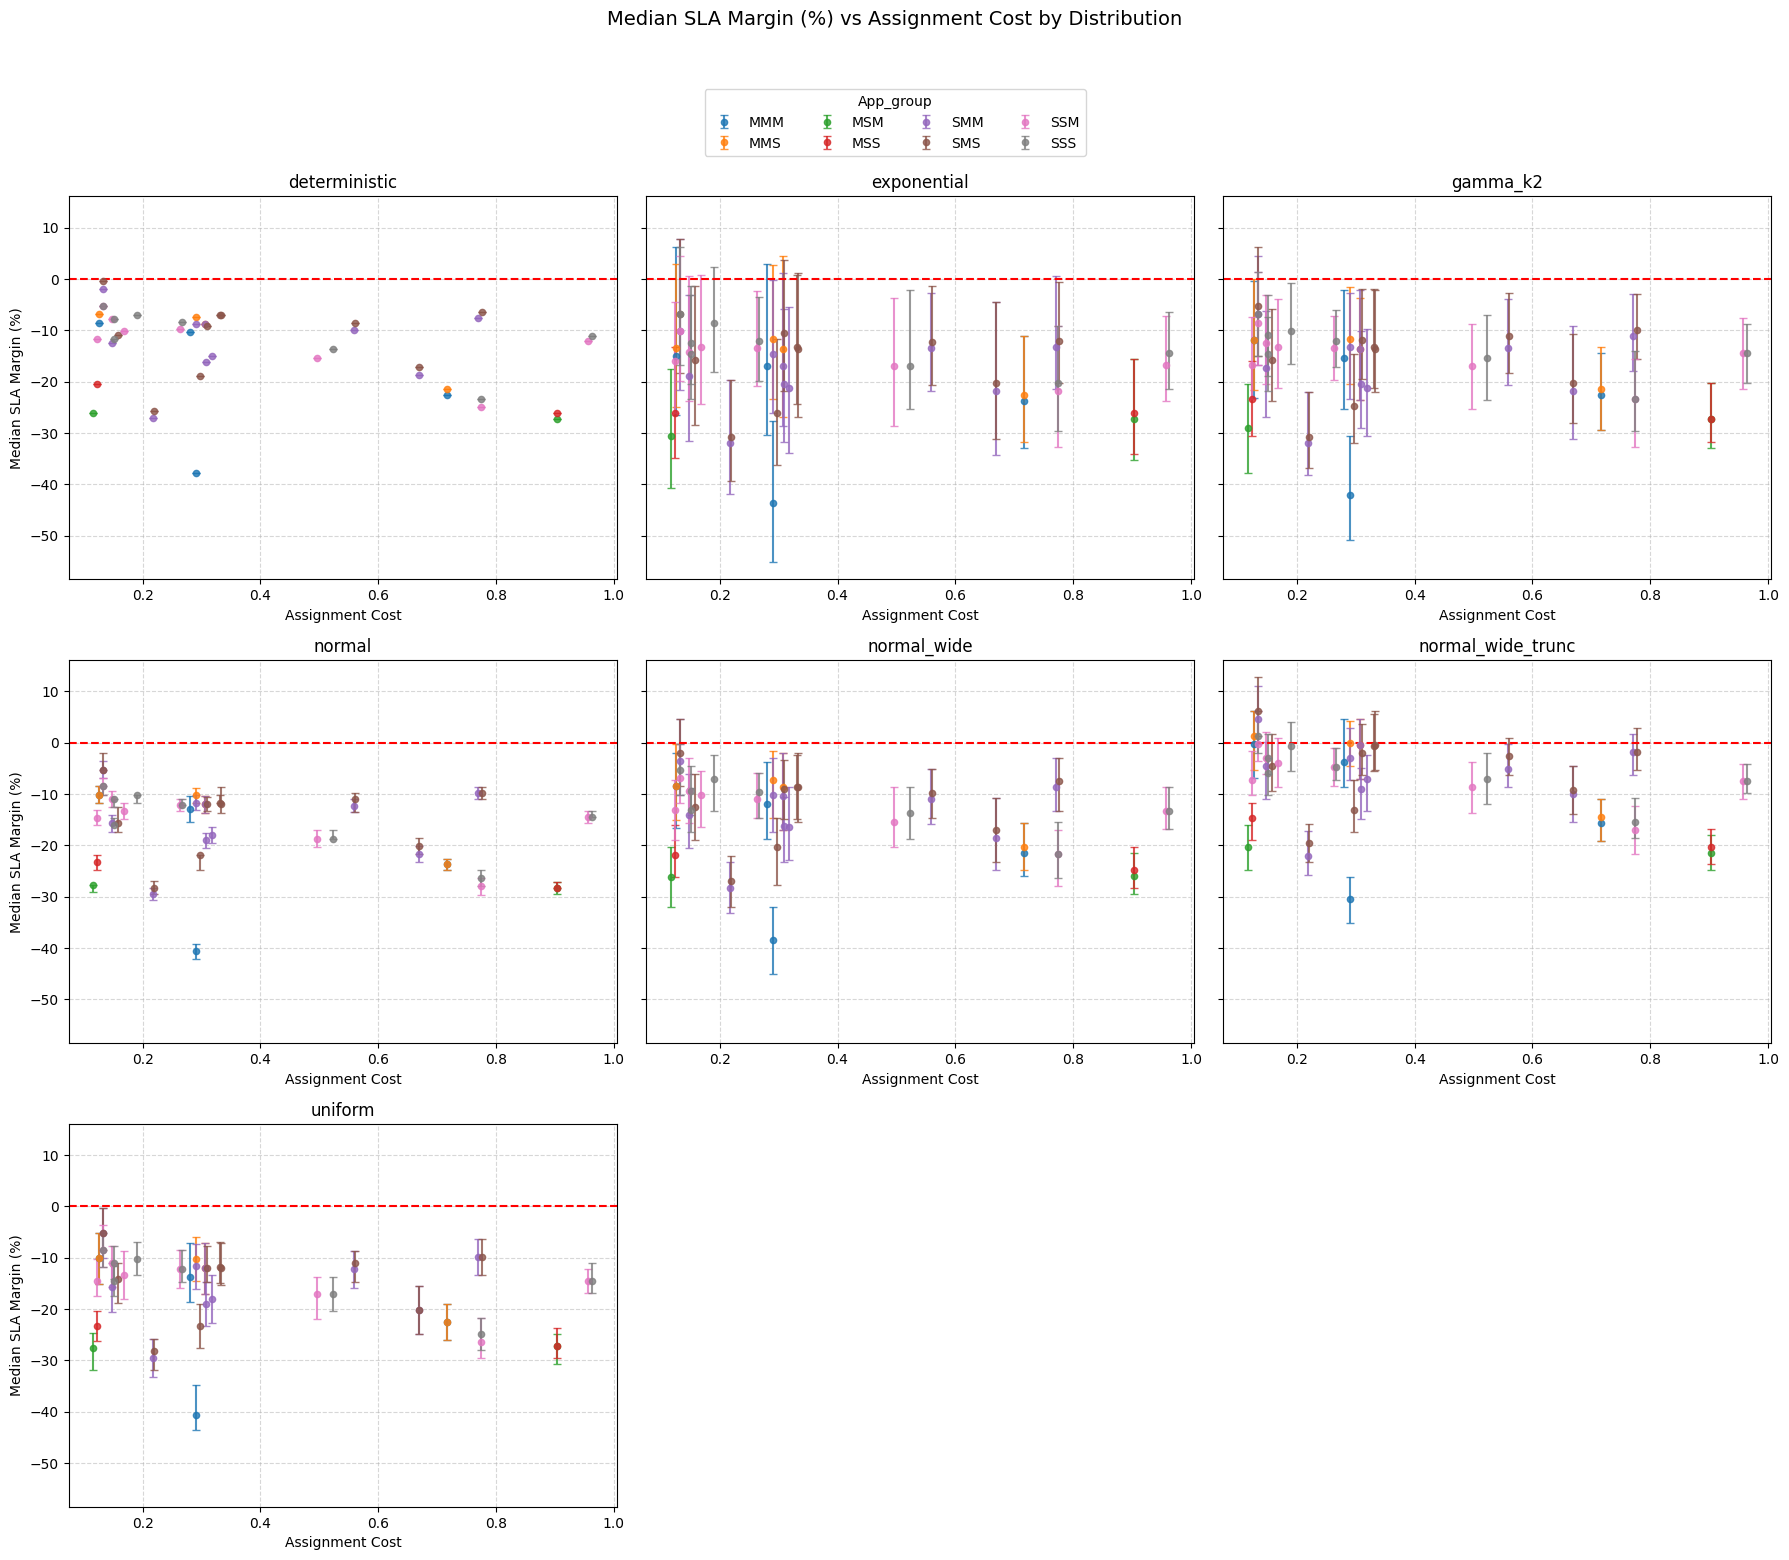

In [74]:
dists = sorted(cost_sla_summary["Distribution"].dropna().unique())

plot_df = cost_sla_summary[
    cost_sla_summary["Distribution"].isin(dists)
].copy()

app_groups = sorted(plot_df["App_group"].dropna().unique())
palette = dict(zip(app_groups, sns.color_palette("tab10", n_colors=len(app_groups))))

ncols = 3
nrows = math.ceil(len(dists) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 4.8 * nrows),
    sharey=True
)

axes = axes.flatten()

y_min = plot_df["Q25_SLA_Margin_Perc"].min()
y_max = plot_df["Q75_SLA_Margin_Perc"].max()
padding = (y_max - y_min) * 0.05 if y_max > y_min else 1
y_lower = y_min - padding
y_upper = y_max + padding

for i, dist in enumerate(dists):
    ax = axes[i]
    subset_dist = plot_df[plot_df["Distribution"] == dist]

    for app_group in app_groups:
        subset = subset_dist[subset_dist["App_group"] == app_group]

        if subset.empty:
            continue

        yerr_lower = subset["Median_SLA_Margin_Perc"] - subset["Q25_SLA_Margin_Perc"]
        yerr_upper = subset["Q75_SLA_Margin_Perc"] - subset["Median_SLA_Margin_Perc"]

        ax.errorbar(
            subset["Assignment_Cost"],
            subset["Median_SLA_Margin_Perc"],
            yerr=[yerr_lower, yerr_upper],
            fmt="o",
            markersize=4.5,
            alpha=0.8,
            capsize=3,
            label=app_group,
            color=palette[app_group]
        )

    ax.axhline(0, linestyle="--", color="red")
    ax.set_title(dist)
    ax.set_xlabel("Assignment Cost")
    ax.set_ylim(y_lower, y_upper)
    ax.grid(True, linestyle="--", alpha=0.5)

    if i % ncols == 0:
        ax.set_ylabel("Median SLA Margin (%)")
    else:
        ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="App_group",
    loc="upper center",
    ncol=min(len(app_groups), 4),
    bbox_to_anchor=(0.5, 1.03)
)

fig.suptitle(
    "Median SLA Margin (%) vs Assignment Cost by Distribution",
    y=1.08,
    fontsize=14
)

plt.tight_layout()
plt.show()

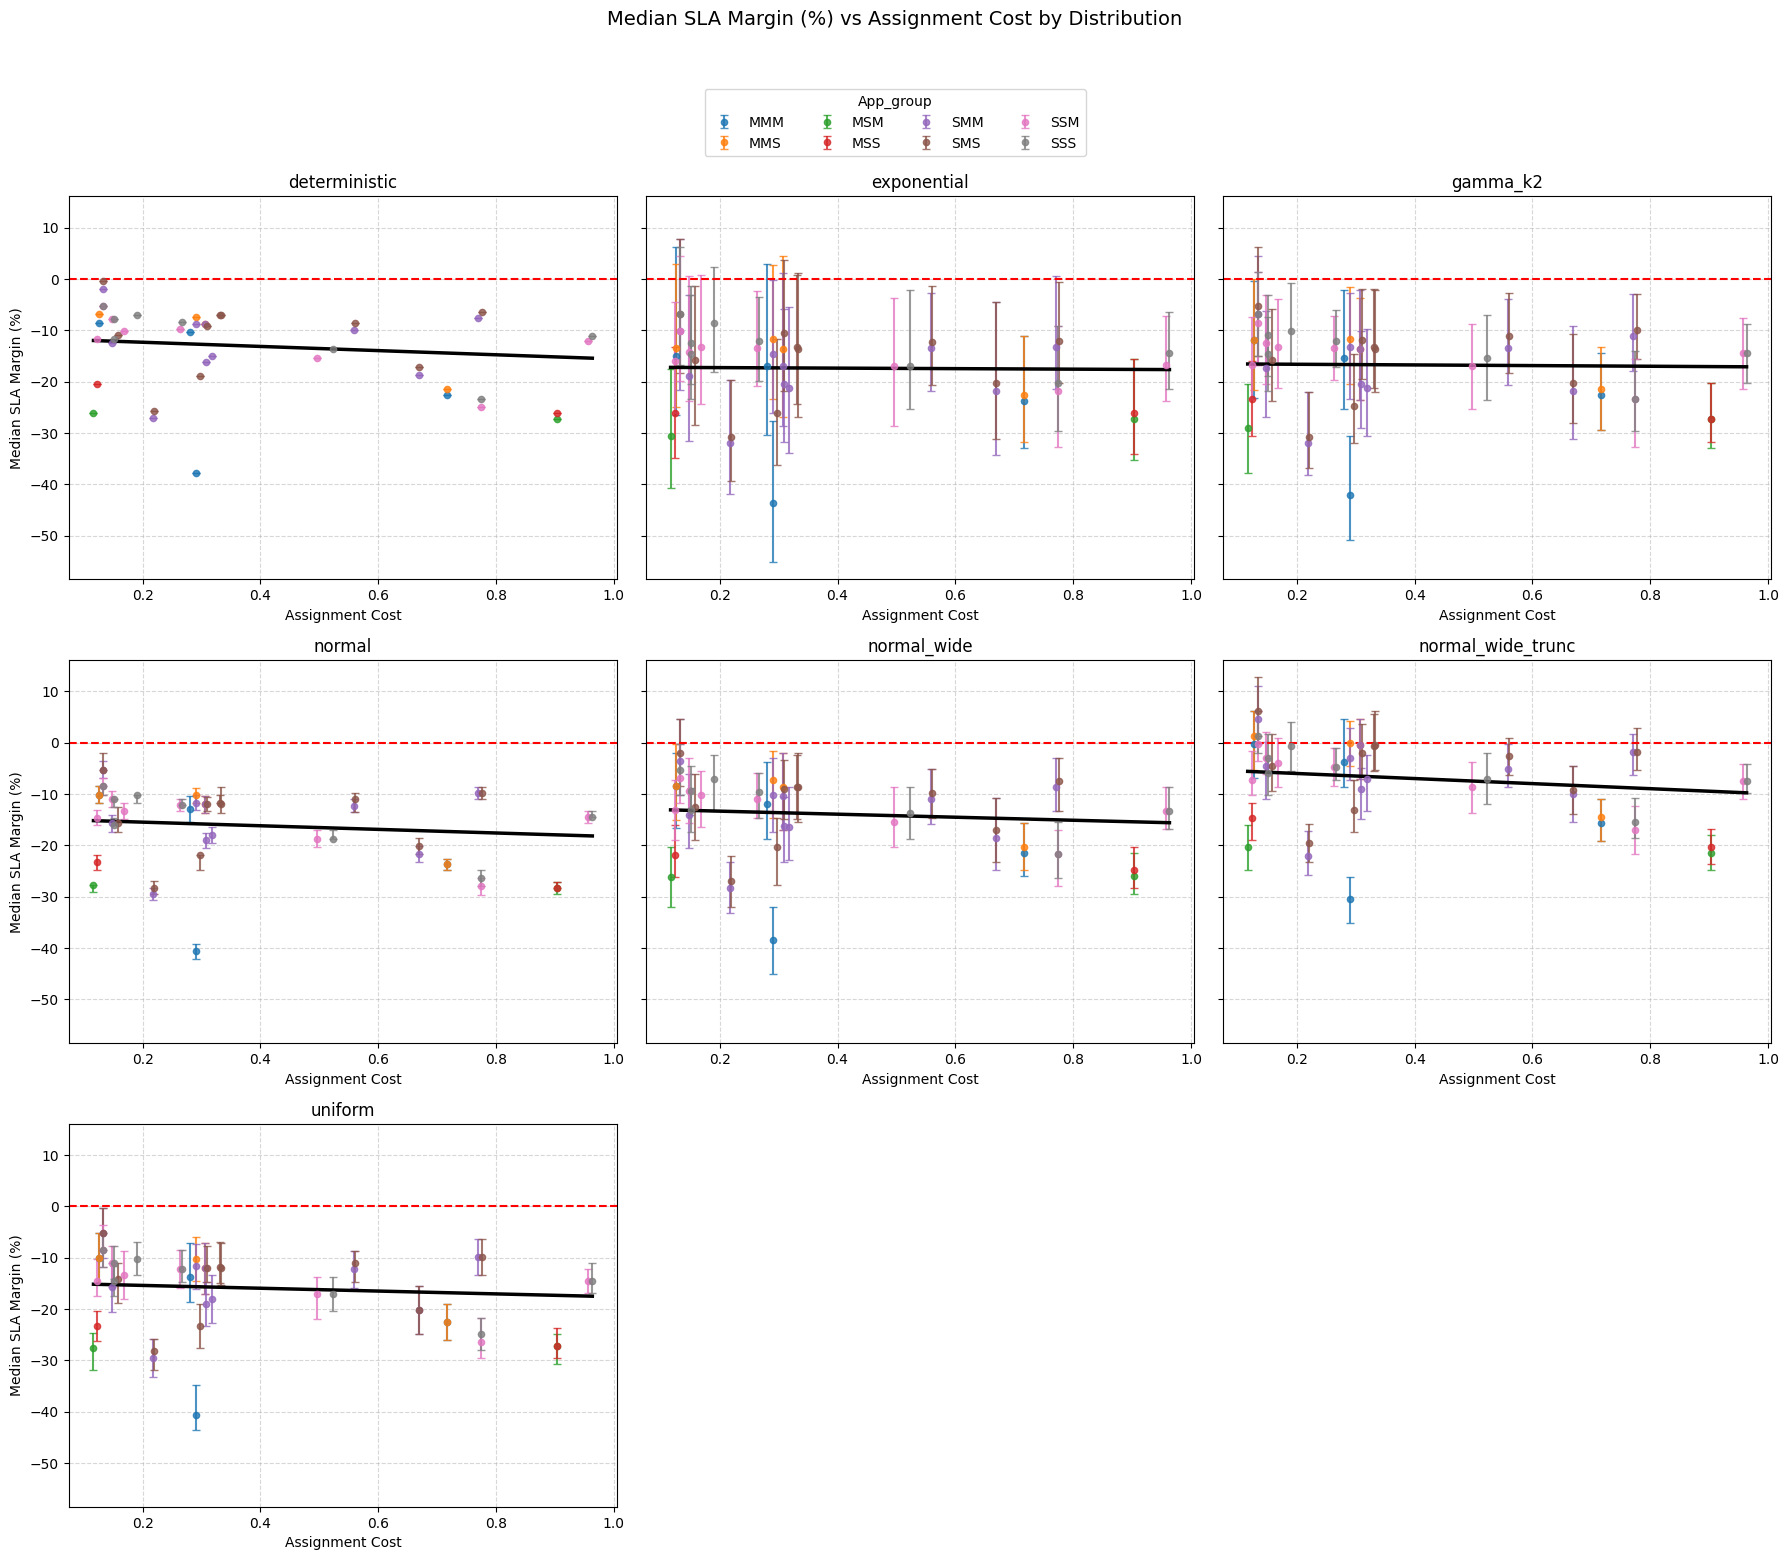

In [75]:
dists = sorted(cost_sla_summary["Distribution"].dropna().unique())

plot_df = cost_sla_summary[
    cost_sla_summary["Distribution"].isin(dists)
].copy()

app_groups = sorted(plot_df["App_group"].dropna().unique())
palette = dict(zip(app_groups, sns.color_palette("tab10", n_colors=len(app_groups))))

ncols = 3
nrows = math.ceil(len(dists) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 4.8 * nrows),
    sharey=True
)

axes = axes.flatten()

y_min = plot_df["Q25_SLA_Margin_Perc"].min()
y_max = plot_df["Q75_SLA_Margin_Perc"].max()
padding = (y_max - y_min) * 0.05 if y_max > y_min else 1
y_lower = y_min - padding
y_upper = y_max + padding

for i, dist in enumerate(dists):
    ax = axes[i]
    subset_dist = plot_df[plot_df["Distribution"] == dist].copy()

    # punti + barre d'errore per App_group
    for app_group in app_groups:
        subset = subset_dist[subset_dist["App_group"] == app_group]

        if subset.empty:
            continue

        yerr_lower = subset["Median_SLA_Margin_Perc"] - subset["Q25_SLA_Margin_Perc"]
        yerr_upper = subset["Q75_SLA_Margin_Perc"] - subset["Median_SLA_Margin_Perc"]

        ax.errorbar(
            subset["Assignment_Cost"],
            subset["Median_SLA_Margin_Perc"],
            yerr=[yerr_lower, yerr_upper],
            fmt="o",
            markersize=4.5,
            alpha=0.8,
            capsize=3,
            label=app_group,
            color=palette[app_group]
        )

    trend_df = (
        subset_dist.groupby("Assignment_Cost")
        .agg(
            Trend_Median=("Median_SLA_Margin_Perc", "median")
        )
        .reset_index()
        .sort_values("Assignment_Cost")
    )

    x = trend_df["Assignment_Cost"].to_numpy()
    y = trend_df["Trend_Median"].to_numpy()

    if len(x) >= 2:
        coeffs = np.polyfit(x, y, deg=1)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = coeffs[0] * x_line + coeffs[1]

        ax.plot(
            x_line,
            y_line,
            color="black",
            linestyle="-",
            linewidth=2.5,
            label="_nolegend_"
        )

    ax.axhline(0, linestyle="--", color="red")
    ax.set_title(dist)
    ax.set_xlabel("Assignment Cost")
    ax.set_ylim(y_lower, y_upper)
    ax.grid(True, linestyle="--", alpha=0.5)

    if i % ncols == 0:
        ax.set_ylabel("Median SLA Margin (%)")
    else:
        ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="App_group",
    loc="upper center",
    ncol=min(len(app_groups), 4),
    bbox_to_anchor=(0.5, 1.03)
)

fig.suptitle(
    "Median SLA Margin (%) vs Assignment Cost by Distribution",
    y=1.08,
    fontsize=14
)

plt.tight_layout()
plt.show()

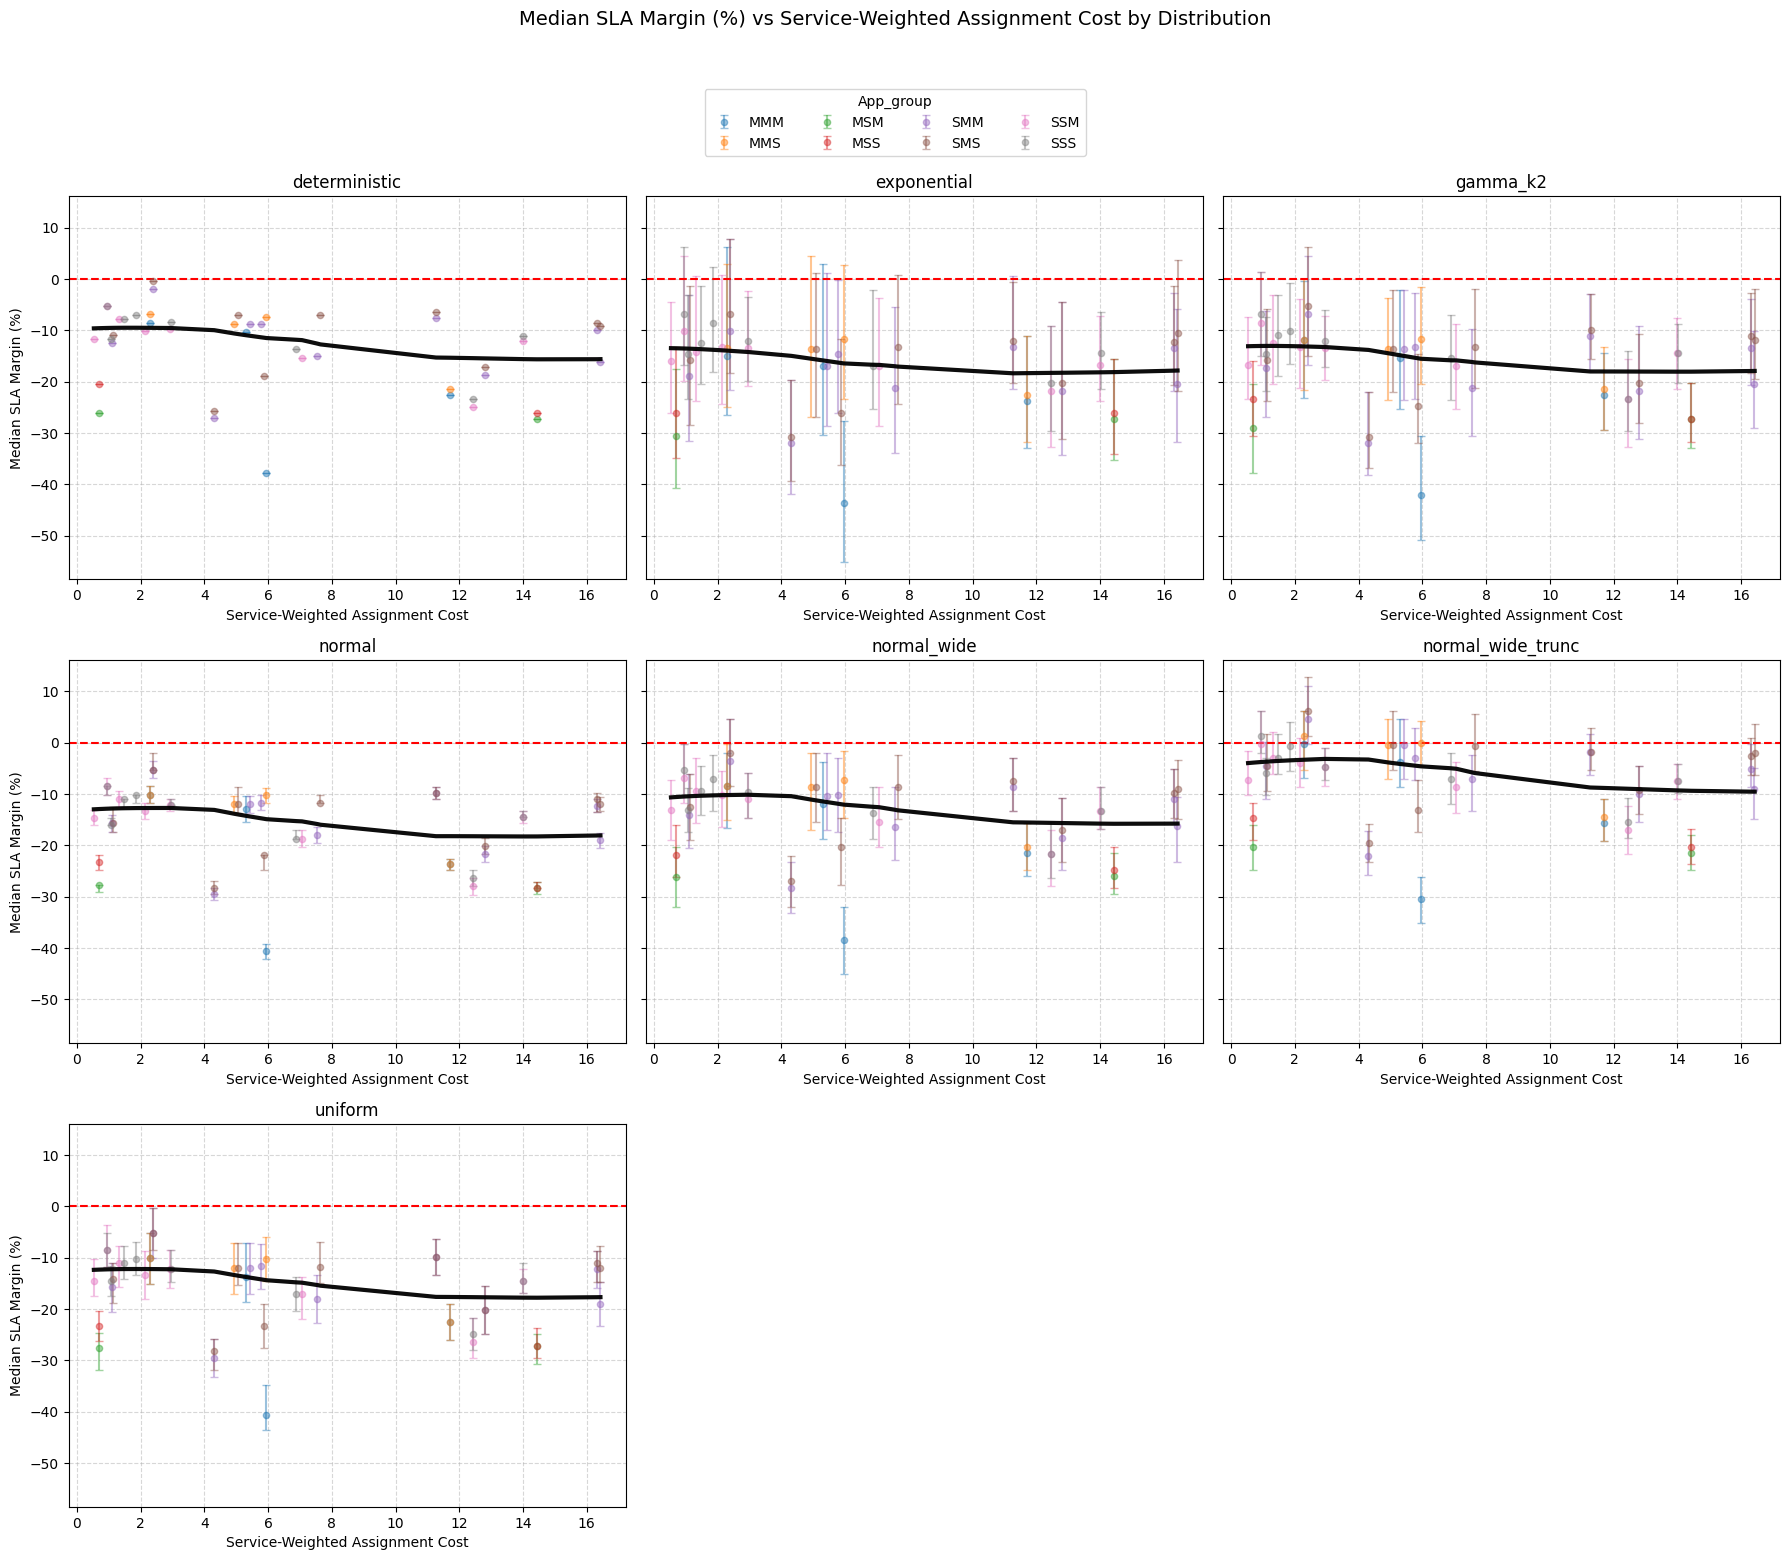

In [76]:
dists = sorted(cost_sla_summary["Distribution"].dropna().unique())

plot_df = cost_sla_summary[
    cost_sla_summary["Distribution"].isin(dists)
].copy()

app_groups = sorted(plot_df["App_group"].dropna().unique())
palette = dict(zip(app_groups, sns.color_palette("tab10", n_colors=len(app_groups))))

ncols = 3
nrows = math.ceil(len(dists) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 4.8 * nrows),
    sharey=True
)

axes = axes.flatten()

y_min = plot_df["Q25_SLA_Margin_Perc"].min()
y_max = plot_df["Q75_SLA_Margin_Perc"].max()
padding = (y_max - y_min) * 0.05 if y_max > y_min else 1
y_lower = y_min - padding
y_upper = y_max + padding

for i, dist in enumerate(dists):
    ax = axes[i]
    subset_dist = plot_df[plot_df["Distribution"] == dist].copy()

    for app_group in app_groups:
        subset = subset_dist[subset_dist["App_group"] == app_group]

        if subset.empty:
            continue

        yerr_lower = subset["Median_SLA_Margin_Perc"] - subset["Q25_SLA_Margin_Perc"]
        yerr_upper = subset["Q75_SLA_Margin_Perc"] - subset["Median_SLA_Margin_Perc"]

        ax.errorbar(
            subset["Service_Weighted_Assignment_Cost"],
            subset["Median_SLA_Margin_Perc"],
            yerr=[yerr_lower, yerr_upper],
            fmt="o",
            markersize=4.5,
            alpha=0.45,
            capsize=3,
            label=app_group,
            color=palette[app_group],
            zorder=2
        )

    if subset_dist["Service_Weighted_Assignment_Cost"].nunique() >= 3:
        sns.regplot(
            data=subset_dist,
            x="Service_Weighted_Assignment_Cost",
            y="Median_SLA_Margin_Perc",
            scatter=False,
            lowess=True,
            ci=None,
            ax=ax,
            line_kws={
                "color": "black",
                "linewidth": 3,
                "alpha": 0.95,
                "zorder": 10
            }
        )

    ax.axhline(0, linestyle="--", color="red")
    ax.set_title(dist)
    ax.set_xlabel("Service-Weighted Assignment Cost")
    ax.set_ylim(y_lower, y_upper)
    ax.grid(True, linestyle="--", alpha=0.5)

    if i % ncols == 0:
        ax.set_ylabel("Median SLA Margin (%)")
    else:
        ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="App_group",
    loc="upper center",
    ncol=min(len(app_groups), 4),
    bbox_to_anchor=(0.5, 1.03)
)

fig.suptitle(
    "Median SLA Margin (%) vs Service-Weighted Assignment Cost by Distribution",
    y=1.08,
    fontsize=14
)

plt.tight_layout()
plt.show()

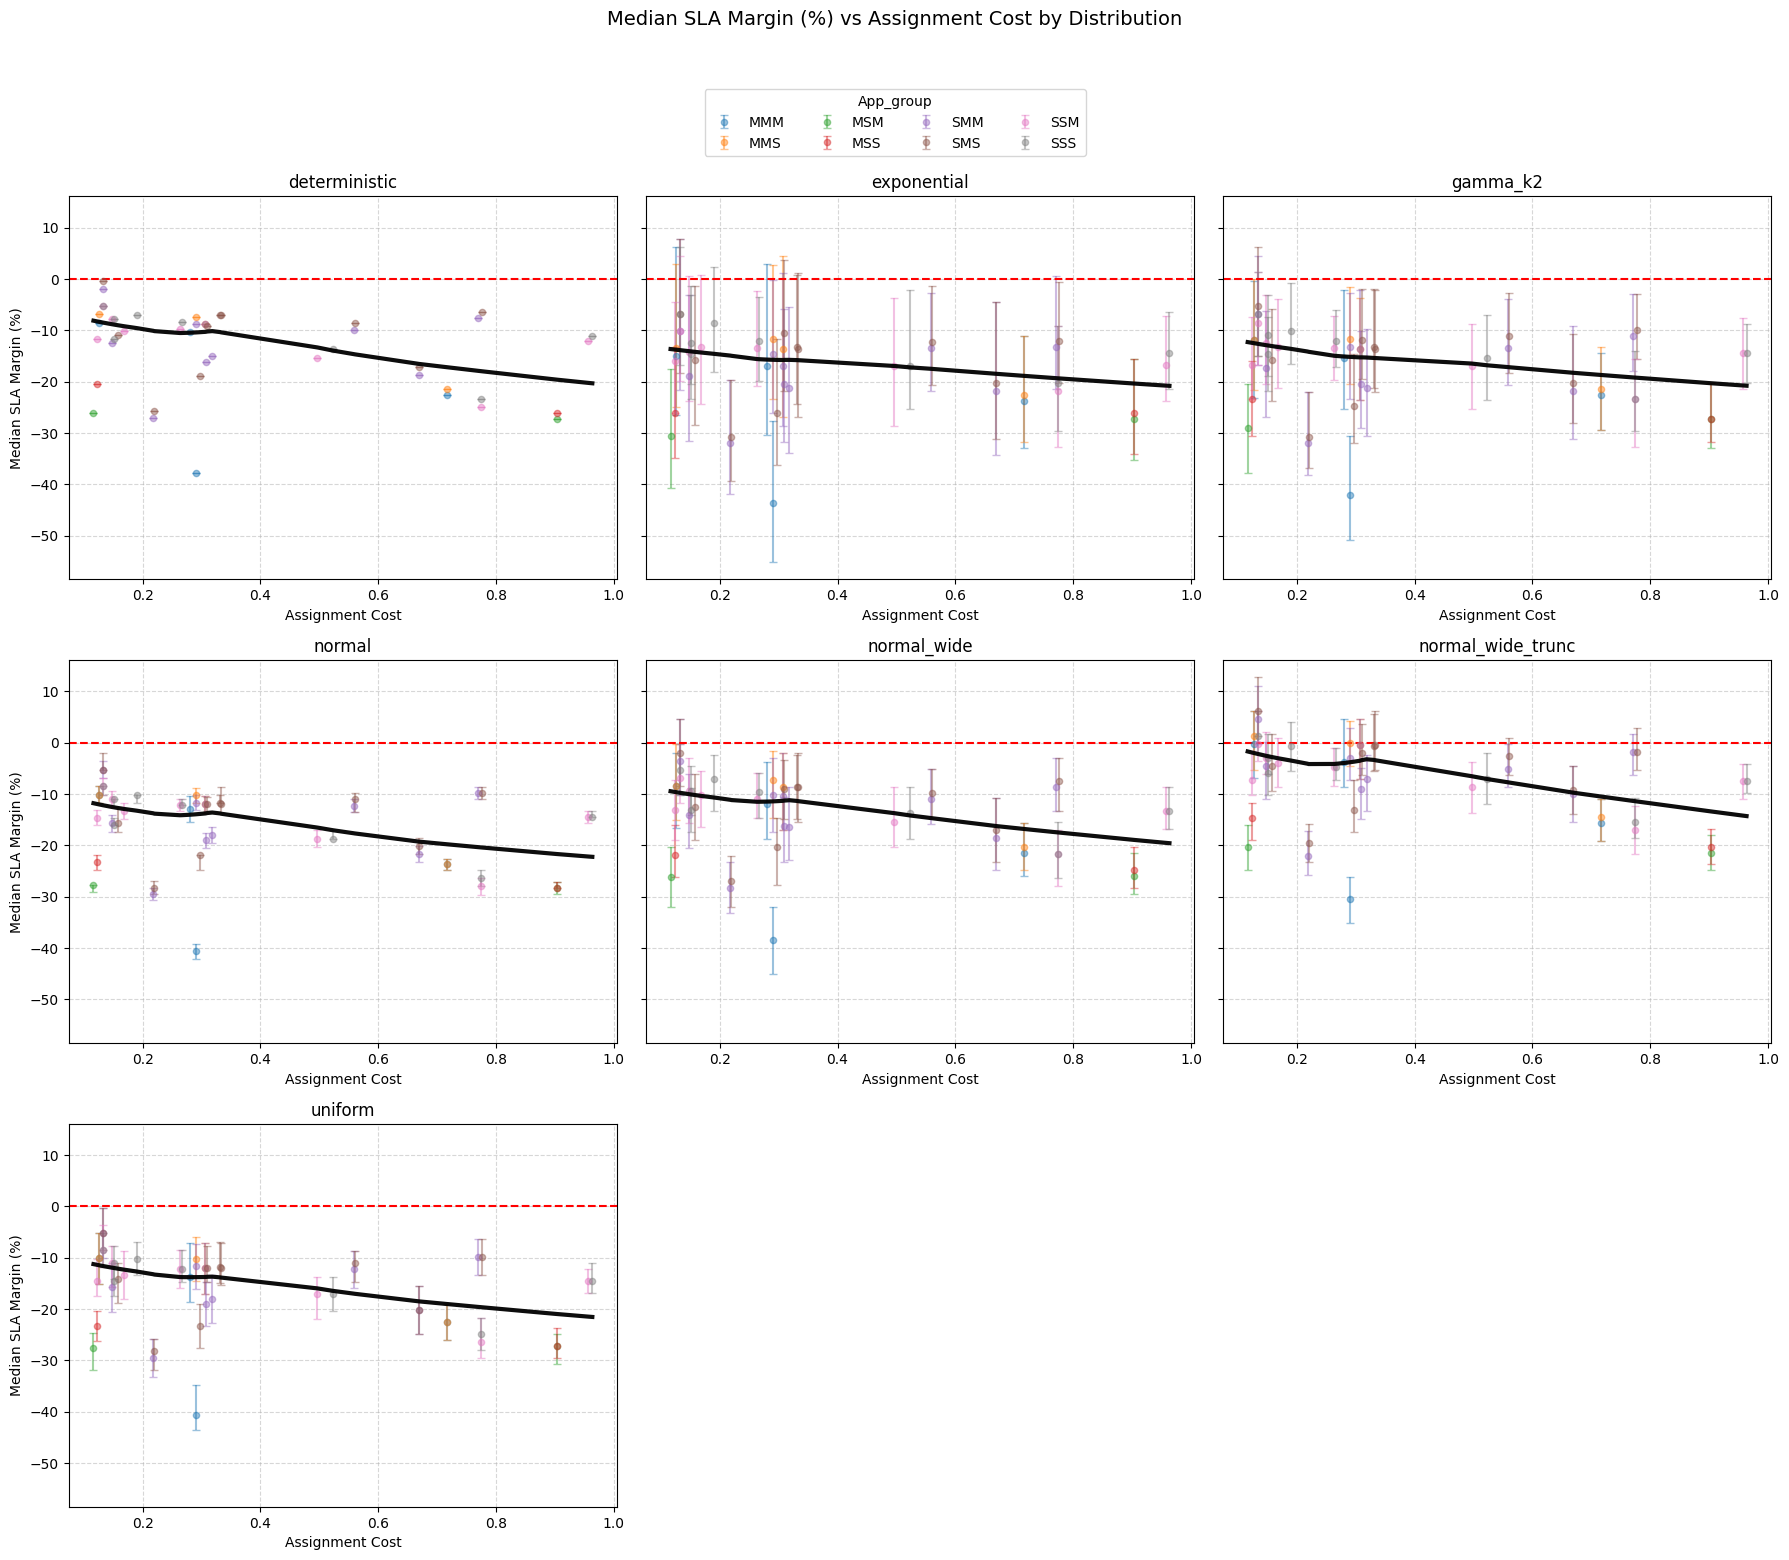

In [77]:
dists = sorted(cost_sla_summary["Distribution"].dropna().unique())

plot_df = cost_sla_summary[
    cost_sla_summary["Distribution"].isin(dists)
].copy()

app_groups = sorted(plot_df["App_group"].dropna().unique())
palette = dict(zip(app_groups, sns.color_palette("tab10", n_colors=len(app_groups))))

ncols = 3
nrows = math.ceil(len(dists) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 4.8 * nrows),
    sharey=True
)

axes = axes.flatten()

y_min = plot_df["Q25_SLA_Margin_Perc"].min()
y_max = plot_df["Q75_SLA_Margin_Perc"].max()
padding = (y_max - y_min) * 0.05 if y_max > y_min else 1
y_lower = y_min - padding
y_upper = y_max + padding

for i, dist in enumerate(dists):
    ax = axes[i]
    subset_dist = plot_df[plot_df["Distribution"] == dist].copy()

    for app_group in app_groups:
        subset = subset_dist[subset_dist["App_group"] == app_group]

        if subset.empty:
            continue

        yerr_lower = subset["Median_SLA_Margin_Perc"] - subset["Q25_SLA_Margin_Perc"]
        yerr_upper = subset["Q75_SLA_Margin_Perc"] - subset["Median_SLA_Margin_Perc"]

        ax.errorbar(
            subset["Assignment_Cost"],
            subset["Median_SLA_Margin_Perc"],
            yerr=[yerr_lower, yerr_upper],
            fmt="o",
            markersize=4.5,
            alpha=0.45,
            capsize=3,
            label=app_group,
            color=palette[app_group],
            zorder=2
        )

    if subset_dist["Assignment_Cost"].nunique() >= 3:
        sns.regplot(
            data=subset_dist,
            x="Assignment_Cost",
            y="Median_SLA_Margin_Perc",
            scatter=False,
            lowess=True,
            ci=None,
            ax=ax,
            line_kws={
                "color": "black",
                "linewidth": 3,
                "alpha": 0.95,
                "zorder": 10
            }
        )

    ax.axhline(0, linestyle="--", color="red")
    ax.set_title(dist)
    ax.set_xlabel("Assignment Cost")
    ax.set_ylim(y_lower, y_upper)
    ax.grid(True, linestyle="--", alpha=0.5)

    if i % ncols == 0:
        ax.set_ylabel("Median SLA Margin (%)")
    else:
        ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="App_group",
    loc="upper center",
    ncol=min(len(app_groups), 4),
    bbox_to_anchor=(0.5, 1.03)
)

fig.suptitle(
    "Median SLA Margin (%) vs Assignment Cost by Distribution",
    y=1.08,
    fontsize=14
)

plt.tight_layout()
plt.show()

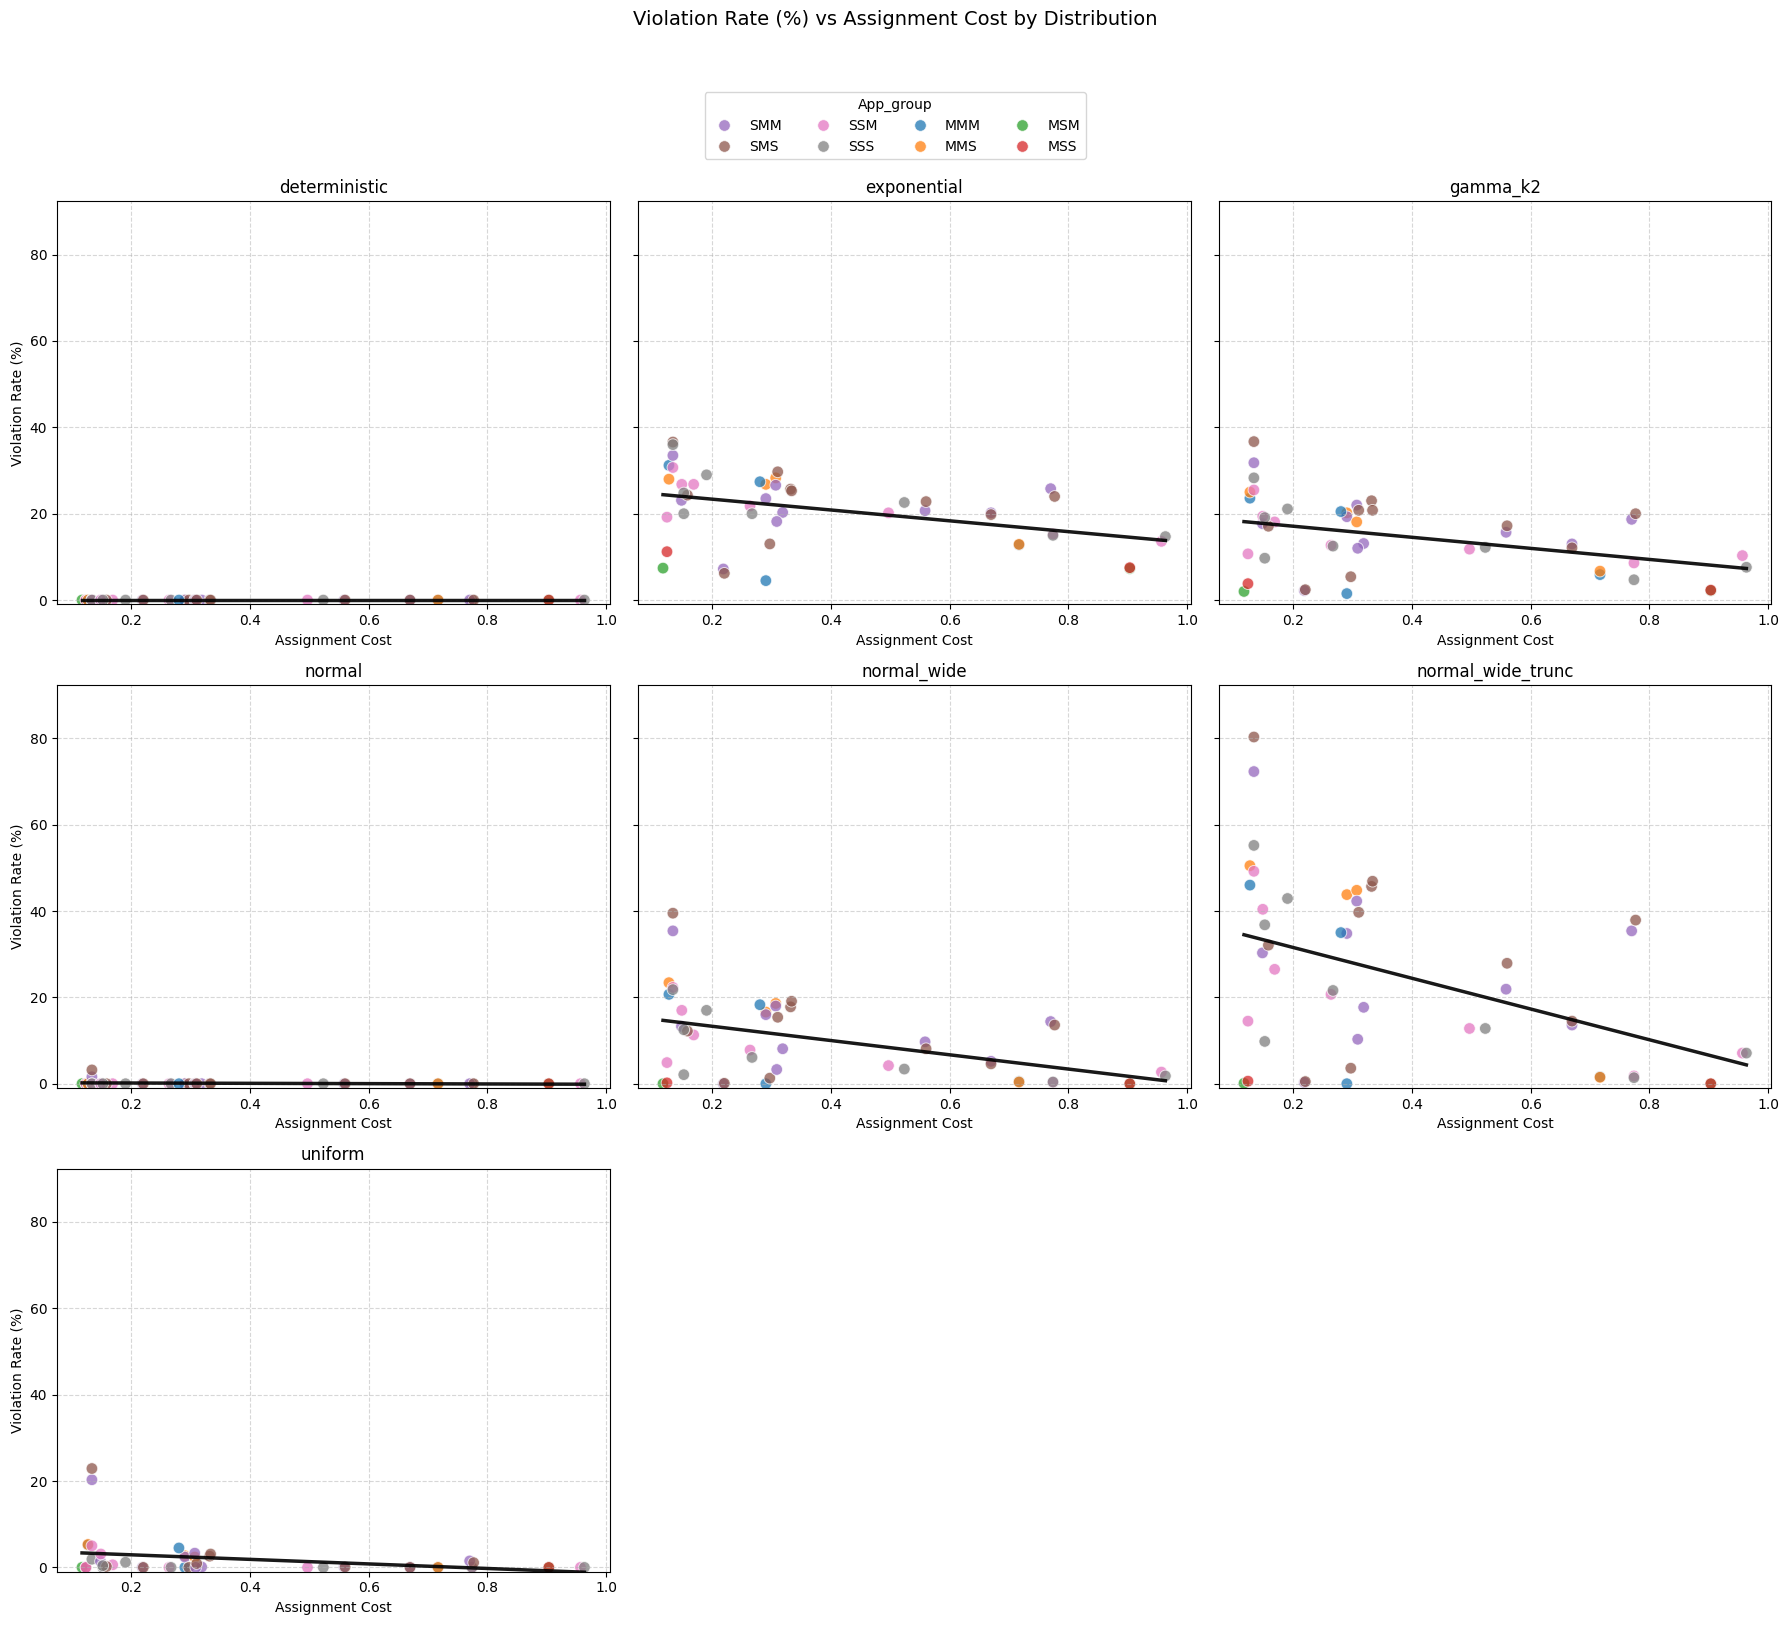

In [78]:
dists = sorted(cost_sla_summary["Distribution"].dropna().unique())

plot_df = cost_sla_summary[
    cost_sla_summary["Distribution"].isin(dists)
].copy()

app_groups = sorted(plot_df["App_group"].dropna().unique())
palette = dict(zip(app_groups, sns.color_palette("tab10", n_colors=len(app_groups))))

ncols = 3
nrows = math.ceil(len(dists) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 5 * nrows),
    sharey=True
)

axes = axes.flatten()

y_upper = max(plot_df["Violation_Rate"].max() * 1.15, 5)

for i, dist in enumerate(dists):
    ax = axes[i]
    subset_dist = plot_df[plot_df["Distribution"] == dist].copy()

    sns.scatterplot(
        data=subset_dist,
        x="Assignment_Cost",
        y="Violation_Rate",
        hue="App_group",
        palette=palette,
        s=70,
        alpha=0.75,
        ax=ax,
        legend=(i == 0)
    )

    sns.regplot(
        data=subset_dist,
        x="Assignment_Cost",
        y="Violation_Rate",
        scatter=False,
        ci=None,
        ax=ax,
        line_kws={
            "color": "black",
            "linewidth": 2.5,
            "alpha": 0.9
        }
    )

    ax.set_title(dist)
    ax.set_xlabel("Assignment Cost")
    ax.set_ylabel("Violation Rate (%)" if i % ncols == 0 else "")
    ax.set_ylim(-1, y_upper)
    ax.grid(True, linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

fig.legend(
    handles,
    labels,
    title="App_group",
    loc="upper center",
    ncol=min(len(app_groups), 4),
    bbox_to_anchor=(0.5, 1.03)
)

fig.suptitle(
    "Violation Rate (%) vs Assignment Cost by Distribution",
    y=1.08,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [79]:
dists = ["normal_wide_trunc", "exponential", "gamma_k2"]

plot_df = cost_sla_summary[
    cost_sla_summary["Distribution"].isin(dists)
].copy()

app_groups = sorted(plot_df["App_group"].dropna().unique())

palette = dict(
    zip(
        app_groups,
        sns.color_palette("tab10", n_colors=len(app_groups))
    )
)

legend_order = app_groups

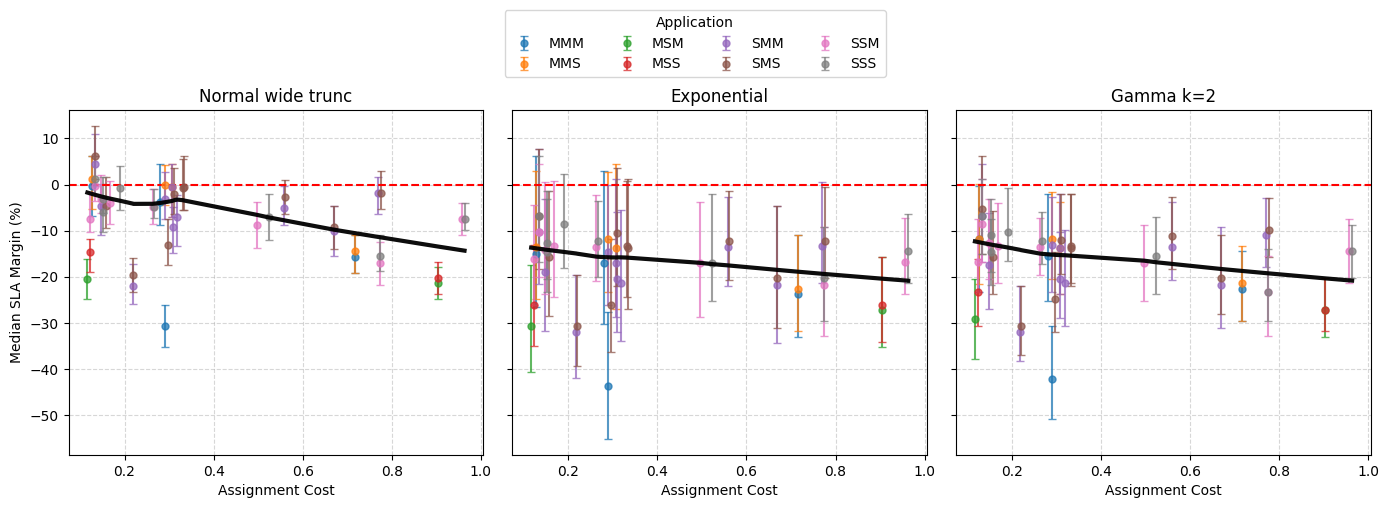

In [80]:
ncols = 3
nrows = 1

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 5),
    sharey=True
)

axes = axes.flatten()

y_min = plot_df["Q25_SLA_Margin_Perc"].min()
y_max = plot_df["Q75_SLA_Margin_Perc"].max()
padding = (y_max - y_min) * 0.05 if y_max > y_min else 1
y_lower = y_min - padding
y_upper = y_max + padding

for i, dist in enumerate(dists):
    ax = axes[i]
    subset_dist = plot_df[plot_df["Distribution"] == dist].copy()

    for app_group in legend_order:
        subset = subset_dist[subset_dist["App_group"] == app_group]

        if subset.empty:
            continue

        yerr_lower = subset["Median_SLA_Margin_Perc"] - subset["Q25_SLA_Margin_Perc"]
        yerr_upper = subset["Q75_SLA_Margin_Perc"] - subset["Median_SLA_Margin_Perc"]

        ax.errorbar(
            subset["Assignment_Cost"],
            subset["Median_SLA_Margin_Perc"],
            yerr=[yerr_lower, yerr_upper],
            fmt="o",
            markersize=5,
            alpha=0.75,
            capsize=3,
            label=app_group,
            color=palette[app_group],
            zorder=2
        )

    if subset_dist["Assignment_Cost"].nunique() >= 3:
        sns.regplot(
            data=subset_dist,
            x="Assignment_Cost",
            y="Median_SLA_Margin_Perc",
            scatter=False,
            lowess=True,
            ci=None,
            ax=ax,
            line_kws={
                "color": "black",
                "linewidth": 3,
                "alpha": 0.95,
                "zorder": 10
            }
        )

    ax.axhline(0, linestyle="--", color="red")
    ax.set_title(distribution_labels.get(dist, dist))
    ax.set_xlabel("Assignment Cost")
    ax.set_ylim(y_lower, y_upper)
    ax.grid(True, linestyle="--", alpha=0.5)

    if i == 0:
        ax.set_ylabel("Median SLA Margin (%)")
    else:
        ax.set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
handle_dict = dict(zip(labels, handles))

ordered_handles = [handle_dict[label] for label in legend_order if label in handle_dict]
ordered_labels = [label for label in legend_order if label in handle_dict]

fig.legend(
    ordered_handles,
    ordered_labels,
    title="Application",
    loc="upper center",
    ncol=min(len(ordered_labels), 4),
    bbox_to_anchor=(0.5, 1.02)
)

# fig.suptitle(
#     "Median SLA Margin (%) vs Assignment Cost",
#     y=1.18,
#     fontsize=14
# )

plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.savefig(
    FIGURES_DIR / "median_sla_margin_vs_assignment_cost_selected.pdf",
    bbox_inches="tight"
)

plt.show()

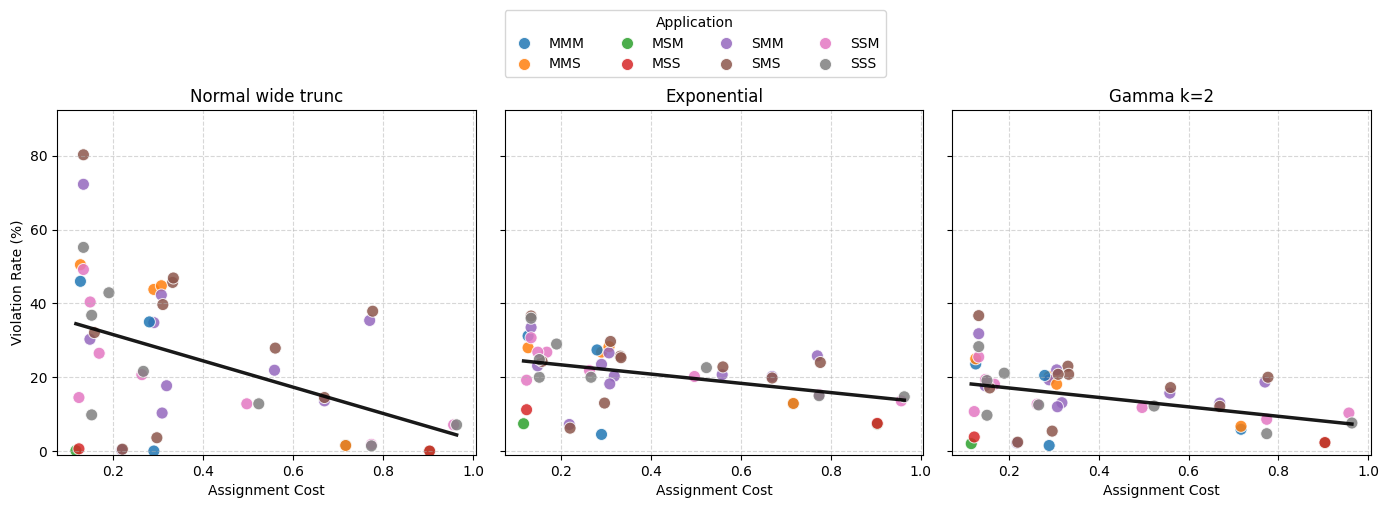

In [81]:
ncols = 3
nrows = 1

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 5),
    sharey=True
)

axes = axes.flatten()

y_upper = max(plot_df["Violation_Rate"].max() * 1.15, 5)

for i, dist in enumerate(dists):
    ax = axes[i]
    subset_dist = plot_df[plot_df["Distribution"] == dist].copy()

    sns.scatterplot(
        data=subset_dist,
        x="Assignment_Cost",
        y="Violation_Rate",
        hue="App_group",
        hue_order=legend_order,
        palette=palette,
        s=75,
        alpha=0.85,
        ax=ax,
        legend=(i == 0)
    )

    sns.regplot(
        data=subset_dist,
        x="Assignment_Cost",
        y="Violation_Rate",
        scatter=False,
        ci=None,
        ax=ax,
        line_kws={
            "color": "black",
            "linewidth": 2.5,
            "alpha": 0.9
        }
    )

    ax.set_title(distribution_labels.get(dist, dist))
    ax.set_xlabel("Assignment Cost")
    ax.set_ylabel("Violation Rate (%)" if i == 0 else "")
    ax.set_ylim(-1, y_upper)
    ax.grid(True, linestyle="--", alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

handle_dict = dict(zip(labels, handles))

ordered_handles = [handle_dict[label] for label in legend_order if label in handle_dict]
ordered_labels = [label for label in legend_order if label in handle_dict]

fig.legend(
    ordered_handles,
    ordered_labels,
    title="Application",
    loc="upper center",
    ncol=min(len(ordered_labels), 4),
    bbox_to_anchor=(0.5, 1.02)
)

# fig.suptitle(
#     "Violation Rate (%) vs Assignment Cost",
#     y=1.12,
#     fontsize=14
# )

plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.savefig(
    FIGURES_DIR / "violation_rate_vs_assignment_cost_selected.pdf",
    bbox_inches="tight"
)

plt.show()

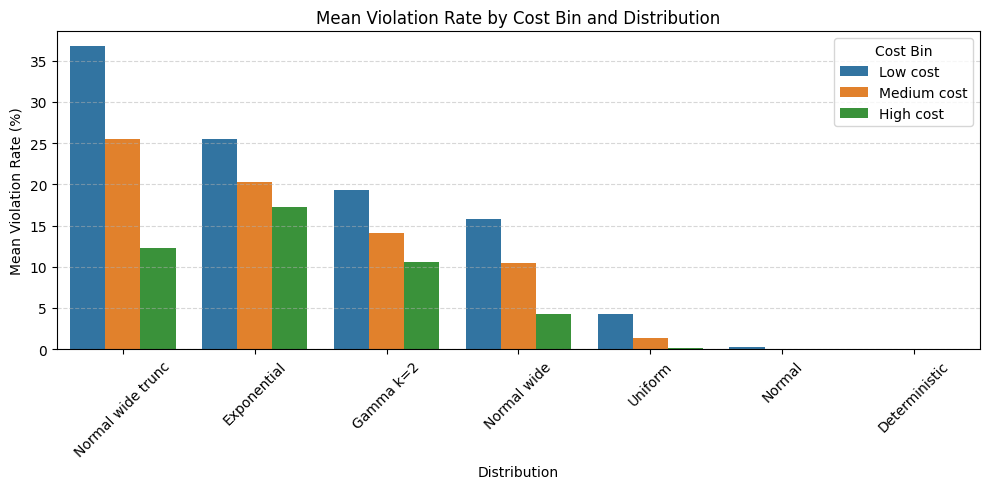

In [82]:
plot_df = cost_sla_summary.copy()

plot_df["Cost_Bin"] = pd.qcut(
    plot_df["Assignment_Cost"],
    q=3,
    labels=["Low cost", "Medium cost", "High cost"],
    duplicates="drop"
)

bin_summary = (
    plot_df
    .groupby(["Distribution", "Cost_Bin"], observed=True)
    .agg(
        Mean_Violation_Rate=("Violation_Rate", "mean"),
        Median_SLA_Margin_Perc=("Median_SLA_Margin_Perc", "median"),
        Config_Count=("Scenario", "count")
    )
    .reset_index()
)

bin_summary["Distribution_Label"] = bin_summary["Distribution"].map(distribution_labels)

distribution_order = (
    bin_summary
    .groupby("Distribution")["Mean_Violation_Rate"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

distribution_order_labels = [
    distribution_labels.get(dist, dist)
    for dist in distribution_order
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=bin_summary,
    x="Distribution_Label",
    y="Mean_Violation_Rate",
    hue="Cost_Bin",
    order=distribution_order_labels,
    hue_order=["Low cost", "Medium cost", "High cost"]
)

plt.legend(title="Cost Bin")

plt.ylabel("Mean Violation Rate (%)")
plt.xlabel("Distribution")
plt.title("Mean Violation Rate by Cost Bin and Distribution")
plt.xticks(rotation=45, ha="center")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "mean_violation_rate_cost_bin.pdf",
    bbox_inches="tight"
)

plt.show()